# 📊 Social Media Marketing Performance Analysis  

---

## 📌 Introduction  

This project analyzes social media marketing data to evaluate campaign effectiveness, user engagement, and conversion performance. Using **400,000+ ad interaction events across 50 campaigns, 200 ads, and 10,000 users**, the study focuses on understanding what drives marketing success.  

Key metrics such as **Click-Through Rate (CTR), Conversion Rate, Funnel Drop, and ROI** are used to measure campaign efficiency. The analysis also explores platform performance, audience behavior, ad creative effectiveness, and time-based trends to uncover actionable insights.  

The goal of this analysis is to provide data-driven recommendations to improve targeting, optimize budget allocation, enhance conversion efficiency, and maximize overall marketing ROI.

---

## 🎯 Objectives  

The main objectives of this analysis are:  

- Analyze the marketing conversion funnel (Impression → Click → Purchase)  
- Evaluate campaign performance using CTR, Conversion Rate, and ROI  
- Identify top-performing campaigns, platforms, and ad formats  
- Understand audience behavior based on age, gender, and geography  
- Measure budget efficiency and ROI across campaigns  
- Identify optimal timing for ad delivery  
- Generate actionable business insights and recommendations

## Importing Libraries:

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Data Loading:

In [3]:
users_df = pd.read_csv(r"users.csv")
campaigns_df = pd.read_csv(r"campaigns.csv")
ads_df = pd.read_csv(r"ads.csv")
ad_events_df = pd.read_csv(r"ad_events.csv")

## Data Understanding (Initial Checks):

### Dataset Overview:
- **Users**: 10,000 user profiles with demographics and interests
- **Campaigns**: 50 marketing campaigns with budget and duration information
- **Ads**: 200 ad creatives across different platforms and types
- **Ad Events**: 400,000 user interaction events (Impressions, Clicks, Purchases, etc.)

In [4]:
print("=== Users Data ===")
users_df.head()

=== Users Data ===


,user_id,user_gender,user_age,age_group,country,location,interests
0,a2474,Female,24,18-24,United Kingdom,New Mariomouth,"fitness, health"
1,141e5,Male,21,18-24,Germany,Danielsfort,"food, fitness, lifestyle"
2,34db0,Male,27,25-34,Australia,Vincentchester,"fashion, news"
3,20d08,Female,28,25-34,India,Lisaport,"health, news, finance"
4,9e830,Male,28,25-34,United States,Brownmouth,"health, photography, lifestyle"


In [5]:
print("\n=== Campaigns Data ===")
campaigns_df.head()


=== Campaigns Data ===


,campaign_id,name,start_date,end_date,duration_days,total_budget
0,1,Campaign_1_Launch,2025-05-25,2025-07-23,59,24021.32
1,2,Campaign_2_Launch,2025-04-16,2025-07-07,82,79342.41
2,3,Campaign_3_Winter,2025-05-04,2025-06-29,56,14343.25
3,4,Campaign_4_Summer,2025-06-04,2025-08-08,65,45326.60
4,5,Campaign_5_Launch,2025-07-11,2025-08-28,48,68376.69


In [6]:
print("\n=== Ads Data ===")
ads_df.head()


=== Ads Data ===


,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,1,28,Facebook,Video,Female,35-44,"art, technology"
1,2,33,Facebook,Stories,All,25-34,"travel, photography"
2,3,20,Instagram,Carousel,All,25-34,technology
3,4,28,Facebook,Stories,Female,25-34,news
4,5,24,Instagram,Image,Female,25-34,news


In [7]:
print("\n=== Ad Events Data ===")
ad_events_df.head()


=== Ad Events Data ===


,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression


In [8]:
print("=== Users Data ===")
print(users_df.info())
print("\n=== Campaigns Data ===")
print(campaigns_df.info())
print("\n=== Ads Data ===")
print(ads_df.info())
print("\n=== Ad Events Data ===")
print(ad_events_df.info())

=== Users Data ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      10000 non-null  str  
 1   user_gender  10000 non-null  str  
 2   user_age     10000 non-null  int64
 3   age_group    10000 non-null  str  
 4   country      10000 non-null  str  
 5   location     10000 non-null  str  
 6   interests    10000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 1.0 MB
None

=== Campaigns Data ===
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   campaign_id    50 non-null     int64  
 1   name           50 non-null     str    
 2   start_date     50 non-null     str    
 3   end_date       50 non-null     str    
 4   duration_days  50 non-null     int64  
 5   total_budget   50 non-null     float64
dtypes:

## Data Cleaning:

### Checking Data Quality:

In [9]:
print("Missing Values:")
print("Users:", users_df.isnull().sum().sum())
print("Campaigns:", campaigns_df.isnull().sum().sum())
print("Ads:", ads_df.isnull().sum().sum())
print("Ad Events:", ad_events_df.isnull().sum().sum())

Missing Values:
Users: 0
Campaigns: 0
Ads: 0
Ad Events: 0


In [10]:
print("=== Users Data ===")
users_df.duplicated().sum()
print("=== Campaigns ===")
campaigns_df.duplicated().sum()
print("=== Ads ===")
ads_df.duplicated().sum()
print("=== Ads Events ===")
ad_events_df.duplicated().sum()

=== Users Data ===
=== Campaigns ===
=== Ads ===
=== Ads Events ===


np.int64(0)

In [11]:
# USERS
users_df['user_id'] = users_df['user_id'].astype('string')
users_df['user_gender'] = users_df['user_gender'].astype('string')
users_df['age_group'] = users_df['age_group'].astype('category')
users_df['country'] = users_df['country'].astype('category')
users_df['location'] = users_df['location'].astype('category')
users_df['interests'] = users_df['interests'].astype('category')

In [12]:
print("=== Users Data ===")
print(users_df.info())

=== Users Data ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   user_id      10000 non-null  string  
 1   user_gender  10000 non-null  string  
 2   user_age     10000 non-null  int64   
 3   age_group    10000 non-null  category
 4   country      10000 non-null  category
 5   location     10000 non-null  category
 6   interests    10000 non-null  category
dtypes: category(4), int64(1), string(2)
memory usage: 592.2 KB
None


In [13]:
# CAMPAIGNS
campaigns_df['start_date'] = pd.to_datetime(campaigns_df['start_date'])
campaigns_df['end_date'] = pd.to_datetime(campaigns_df['end_date'])
campaigns_df['name'] = campaigns_df['name'].astype('category')

In [14]:
print("\n=== Campaigns Data ===")
print(campaigns_df.info())


=== Campaigns Data ===
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_id    50 non-null     int64         
 1   name           50 non-null     category      
 2   start_date     50 non-null     datetime64[us]
 3   end_date       50 non-null     datetime64[us]
 4   duration_days  50 non-null     int64         
 5   total_budget   50 non-null     float64       
dtypes: category(1), datetime64[us](2), float64(1), int64(2)
memory usage: 3.4 KB
None


In [15]:
# ADS
ads_df['ad_platform'] = ads_df['ad_platform'].astype('category')
ads_df['ad_type'] = ads_df['ad_type'].astype('category')
ads_df['target_gender'] = ads_df['target_gender'].astype('category')
ads_df['target_age_group'] = ads_df['target_age_group'].astype('category')
ads_df['target_interests'] = ads_df['target_interests'].astype('category')

In [16]:
print("\n=== Ads Data ===")
print(ads_df.info())


=== Ads Data ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   ad_id             200 non-null    int64   
 1   campaign_id       200 non-null    int64   
 2   ad_platform       200 non-null    category
 3   ad_type           200 non-null    category
 4   target_gender     200 non-null    category
 5   target_age_group  200 non-null    category
 6   target_interests  200 non-null    category
dtypes: category(5), int64(2)
memory usage: 6.4 KB
None


In [17]:
# AD EVENTS
ad_events_df['timestamp'] = pd.to_datetime(ad_events_df['timestamp'])
ad_events_df['day_of_week'] = ad_events_df['day_of_week'].astype('category')
ad_events_df['time_of_day'] = ad_events_df['time_of_day'].astype('category')
ad_events_df['event_type'] = ad_events_df['event_type'].astype('category')

In [18]:
print("\n=== Ad Events Data ===")
print(ad_events_df.info())


=== Ad Events Data ===
<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   event_id     400000 non-null  int64         
 1   ad_id        400000 non-null  int64         
 2   user_id      400000 non-null  str           
 3   timestamp    400000 non-null  datetime64[us]
 4   day_of_week  400000 non-null  category      
 5   time_of_day  400000 non-null  category      
 6   event_type   400000 non-null  category      
dtypes: category(3), datetime64[us](1), int64(2), str(1)
memory usage: 15.3 MB
None


## Data Pre-Processing:

### Merging Datasets:
Creating a unified dataset by merging all tables to enable comprehensive analysis.

In [19]:
df = ad_events_df.merge(users_df, on='user_id', how='left') \
              .merge(ads_df, on='ad_id', how='left') \
              .merge(campaigns_df, on='campaign_id', how='left')
df.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,user_gender,user_age,age_group,...,ad_platform,ad_type,target_gender,target_age_group,target_interests,name,start_date,end_date,duration_days,total_budget
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,Female,24,18-24,...,Facebook,Stories,All,All,"lifestyle, gaming",Campaign_9_Launch,2025-05-25,2025-07-13,49,40094.07
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,Female,30,25-34,...,Instagram,Carousel,All,18-24,photography,Campaign_26_Winter,2025-04-01,2025-06-17,77,44538.87
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,Male,20,18-24,...,Instagram,Carousel,All,35-44,"technology, travel",Campaign_10_Winter,2025-05-17,2025-07-21,65,19669.27
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,Female,18,18-24,...,Instagram,Image,All,All,fashion,Campaign_14_Summer,2025-04-15,2025-06-04,50,39849.94
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,Male,58,55-65,...,Instagram,Stories,Female,35-44,"health, lifestyle",Campaign_2_Launch,2025-04-16,2025-07-07,82,79342.41


In [20]:
df.shape

(403967, 24)

In [21]:
df['impression'] = np.where(df['event_type']=='Impression',1,0)
df['click'] = np.where(df['event_type']=='Click',1,0)
df['purchase'] = np.where(df['event_type']=='Purchase',1,0)
df.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,user_gender,user_age,age_group,...,target_age_group,target_interests,name,start_date,end_date,duration_days,total_budget,impression,click,purchase
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,Female,24,18-24,...,All,"lifestyle, gaming",Campaign_9_Launch,2025-05-25,2025-07-13,49,40094.07,0,0,0
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,Female,30,25-34,...,18-24,photography,Campaign_26_Winter,2025-04-01,2025-06-17,77,44538.87,0,0,0
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,Male,20,18-24,...,35-44,"technology, travel",Campaign_10_Winter,2025-05-17,2025-07-21,65,19669.27,1,0,0
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,Female,18,18-24,...,All,fashion,Campaign_14_Summer,2025-04-15,2025-06-04,50,39849.94,1,0,0
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,Male,58,55-65,...,35-44,"health, lifestyle",Campaign_2_Launch,2025-04-16,2025-07-07,82,79342.41,1,0,0


In [22]:
ctr = df['click'].sum() / df['impression'].sum()
conversion_rate = df['purchase'].sum() / df['click'].sum()
print("CTR:", ctr)
print("Conversion Rate:", conversion_rate)

CTR: 0.1180072095280003
Conversion Rate: 0.05062353376960119


## Exploratory Data Analysis:

This section provides comprehensive insights into marketing campaign performance, user behavior, and conversion patterns.

## ROI Analysis:

In [23]:
roi = df.groupby('name')['purchase'].sum() / df.groupby('name')['total_budget'].first()
roi.sort_values(ascending=False).head(10)

name
Campaign_42_Summer    0.008462
Campaign_29_Winter    0.003034
Campaign_3_Winter     0.002998
Campaign_13_Winter    0.002974
Campaign_34_Winter    0.002643
Campaign_10_Winter    0.002593
Campaign_27_Q3        0.002541
Campaign_44_Q3        0.002451
Campaign_23_Winter    0.001615
Campaign_9_Launch     0.001571
dtype: float64

## Correlation Heatmap:

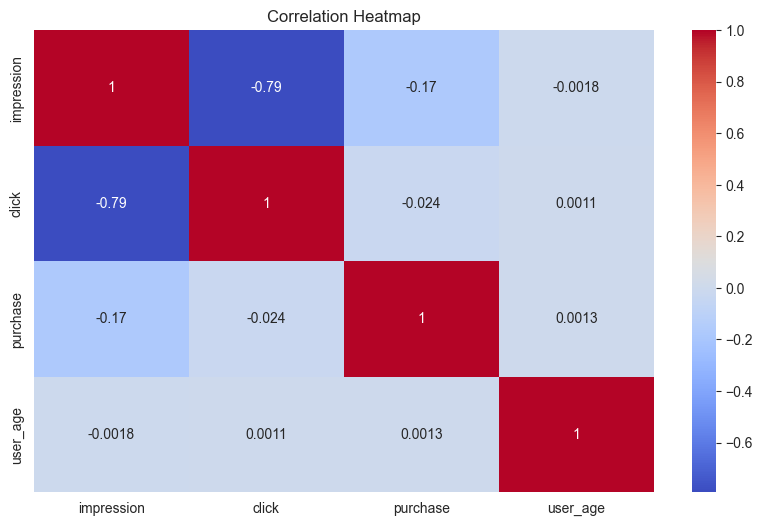

In [24]:
sns.heatmap(df[['impression','click','purchase','user_age']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### 1. Funnel Analysis:

Understanding the conversion funnel from impressions to purchases.

In [25]:
funnel_counts = df[['impression','click','purchase']].sum()

print(funnel_counts)

impression    343157
click          40495
purchase        2050
dtype: int64


In [26]:
impressions = funnel_counts['impression']
clicks = funnel_counts['click']
purchases = funnel_counts['purchase']

click_drop = 1 - (clicks / impressions)
purchase_drop = 1 - (purchases / clicks)

print("Drop from Impression → Click:", click_drop)
print("Drop from Click → Purchase:", purchase_drop)

Drop from Impression → Click: 0.8819927904719997
Drop from Click → Purchase: 0.9493764662303988


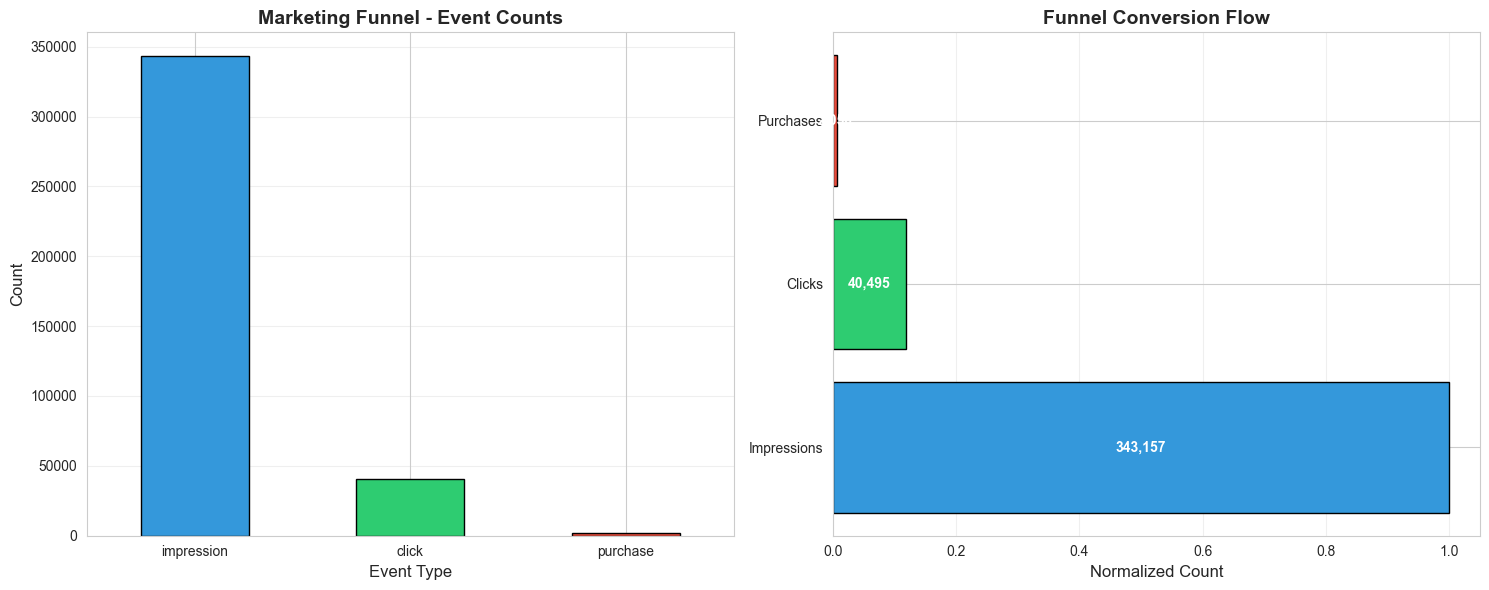


📊 Key Metrics:
   • Click-Through Rate (CTR): 11.80%
   • Conversion Rate (Click to Purchase): 5.06%
   • Overall Conversion Rate (Impression to Purchase): 0.60%

💡 Insight: Out of 343,157 impressions, only 2,050 resulted in purchases (0.60%).
   The largest drop occurs at the impression-to-click stage (88.2% drop).


In [27]:
# Enhanced Funnel Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
funnel_counts.plot(kind='bar', ax=ax1, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
ax1.set_title("Marketing Funnel - Event Counts", fontsize=14, fontweight='bold')
ax1.set_ylabel("Count", fontsize=12)
ax1.set_xlabel("Event Type", fontsize=12)
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Funnel visualization
funnel_data = [impressions, clicks, purchases]
funnel_labels = ['Impressions', 'Clicks', 'Purchases']
colors = ['#3498db', '#2ecc71', '#e74c3c']
y_pos = np.arange(len(funnel_labels))
widths = [val/max(funnel_data) for val in funnel_data]

ax2.barh(y_pos, widths, color=colors, edgecolor='black')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(funnel_labels)
ax2.set_xlabel("Normalized Count", fontsize=12)
ax2.set_title("Funnel Conversion Flow", fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (val, width) in enumerate(zip(funnel_data, widths)):
    ax2.text(width/2, i, f'{val:,}', ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

# Calculate and display conversion rates
ctr_pct = ctr * 100
conv_rate_pct = conversion_rate * 100
print(f"\n📊 Key Metrics:")
print(f"   • Click-Through Rate (CTR): {ctr_pct:.2f}%")
print(f"   • Conversion Rate (Click to Purchase): {conv_rate_pct:.2f}%")
print(f"   • Overall Conversion Rate (Impression to Purchase): {(purchases/impressions)*100:.2f}%")
print(f"\n💡 Insight: Out of {impressions:,} impressions, only {purchases:,} resulted in purchases ({purchases/impressions*100:.2f}%).")
print(f"   The largest drop occurs at the impression-to-click stage (88.2% drop).")

### 2. Campaign Performance:

Analyzing which campaigns drive the most conversions and ROI.

In [28]:
campaign_perf = df.groupby('name')[['impression','click','purchase']].sum().sort_values(by='purchase', ascending=False)

# Calculate CTR and Conversion Rate for each campaign
campaign_perf['CTR'] = (campaign_perf['click'] / campaign_perf['impression']) * 100
campaign_perf['Conv_Rate'] = (campaign_perf['purchase'] / campaign_perf['click']) * 100
campaign_perf['Overall_Conv_Rate'] = (campaign_perf['purchase'] / campaign_perf['impression']) * 100

print("Top 10 Campaigns by Purchase Count:")
print("="*80)
campaign_perf.head(10)

Top 10 Campaigns by Purchase Count:


,impression,click,purchase,CTR,Conv_Rate,Overall_Conv_Rate
name,,,,,,
Campaign_38_Q3,13550,1610,97,11.881919,6.024845,0.715867
Campaign_17_Launch,13653,1668,91,12.217095,5.455635,0.666520
Campaign_33_Summer,12155,1415,86,11.641300,6.077739,0.707528
Campaign_24_Summer,13756,1590,81,11.558593,5.094340,0.588834
Campaign_20_Winter,13727,1672,73,12.180374,4.366029,0.531799
Campaign_34_Winter,10306,1251,69,12.138560,5.515588,0.669513
Campaign_42_Summer,13814,1621,67,11.734472,4.133251,0.485015
Campaign_13_Winter,10424,1226,65,11.761320,5.301794,0.623561
Campaign_9_Launch,10461,1237,63,11.824873,5.092967,0.602237


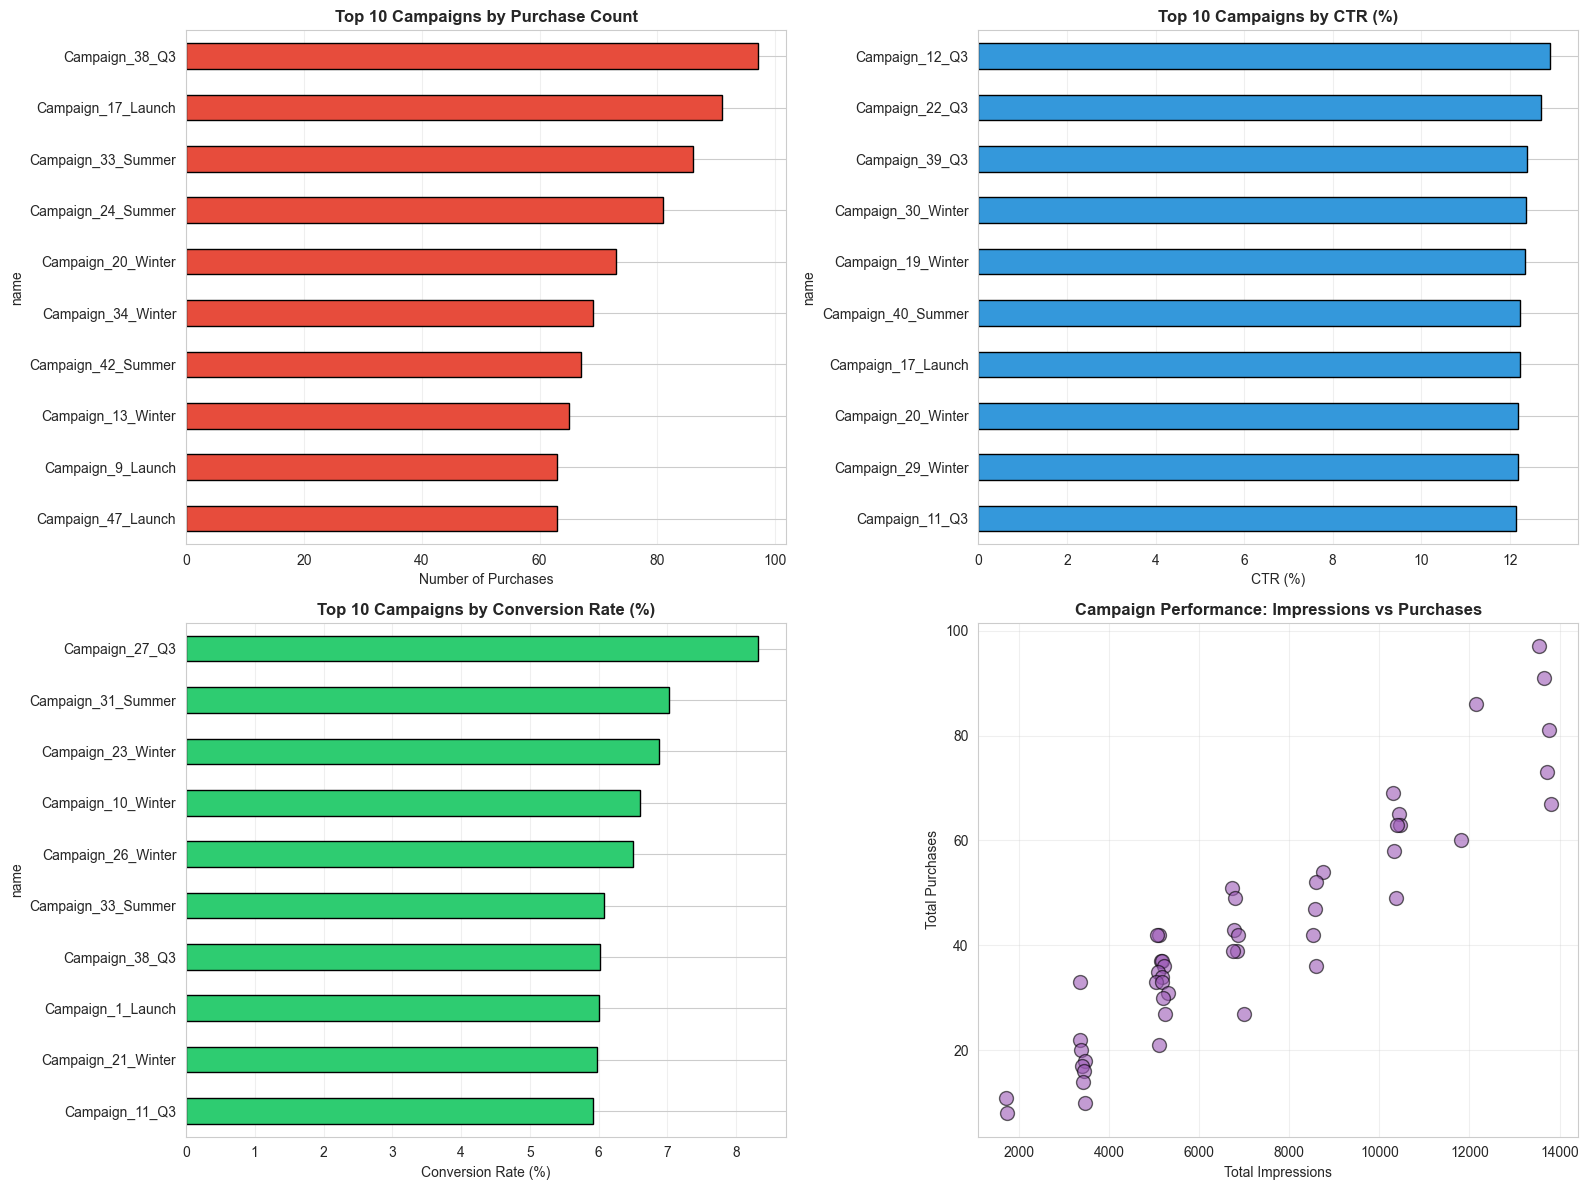


💡 Key Insights:
   • Best performing campaign: Campaign_38_Q3 with 97 purchases
   • Average CTR across all campaigns: 11.76%
   • Average Conversion Rate: 5.10%
   • Campaigns with highest CTR may not always have highest purchases - indicating targeting vs volume trade-off


In [29]:
# Enhanced Campaign Performance Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 campaigns by purchases
top_campaigns = campaign_perf.head(10)
top_campaigns['purchase'].plot(kind='barh', ax=axes[0,0], color='#e74c3c', edgecolor='black')
axes[0,0].set_title("Top 10 Campaigns by Purchase Count", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Number of Purchases", fontsize=10)
axes[0,0].invert_yaxis()
axes[0,0].grid(axis='x', alpha=0.3)

# Top 10 campaigns by CTR
top_ctr = campaign_perf.nlargest(10, 'CTR')
top_ctr['CTR'].plot(kind='barh', ax=axes[0,1], color='#3498db', edgecolor='black')
axes[0,1].set_title("Top 10 Campaigns by CTR (%)", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("CTR (%)", fontsize=10)
axes[0,1].invert_yaxis()
axes[0,1].grid(axis='x', alpha=0.3)

# Top 10 campaigns by Conversion Rate
top_conv = campaign_perf.nlargest(10, 'Conv_Rate')
top_conv['Conv_Rate'].plot(kind='barh', ax=axes[1,0], color='#2ecc71', edgecolor='black')
axes[1,0].set_title("Top 10 Campaigns by Conversion Rate (%)", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Conversion Rate (%)", fontsize=10)
axes[1,0].invert_yaxis()
axes[1,0].grid(axis='x', alpha=0.3)

# Campaign performance scatter (Impressions vs Purchases)
axes[1,1].scatter(campaign_perf['impression'], campaign_perf['purchase'], 
                  s=100, alpha=0.6, color='#9b59b6', edgecolor='black')
axes[1,1].set_title("Campaign Performance: Impressions vs Purchases", fontsize=12, fontweight='bold')
axes[1,1].set_xlabel("Total Impressions", fontsize=10)
axes[1,1].set_ylabel("Total Purchases", fontsize=10)
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
print(f"   • Best performing campaign: {top_campaigns.index[0]} with {top_campaigns.iloc[0]['purchase']:.0f} purchases")
print(f"   • Average CTR across all campaigns: {campaign_perf['CTR'].mean():.2f}%")
print(f"   • Average Conversion Rate: {campaign_perf['Conv_Rate'].mean():.2f}%")
print(f"   • Campaigns with highest CTR may not always have highest purchases - indicating targeting vs volume trade-off")

### 3. Platform Performance:

Comparing Facebook vs Instagram performance across key metrics.

In [30]:
platform_perf = df.groupby('ad_platform')[['impression','click','purchase']].sum()

# Calculate metrics
platform_perf['CTR'] = (platform_perf['click'] / platform_perf['impression']) * 100
platform_perf['Conv_Rate'] = (platform_perf['purchase'] / platform_perf['click']) * 100
platform_perf['Overall_Conv_Rate'] = (platform_perf['purchase'] / platform_perf['impression']) * 100

print("Platform Performance Summary:")
print("="*80)
platform_perf

Platform Performance Summary:


,impression,click,purchase,CTR,Conv_Rate,Overall_Conv_Rate
ad_platform,,,,,,
Facebook,218042,25641,1333,11.759661,5.198705,0.611350
Instagram,125115,14854,717,11.872278,4.826983,0.573073


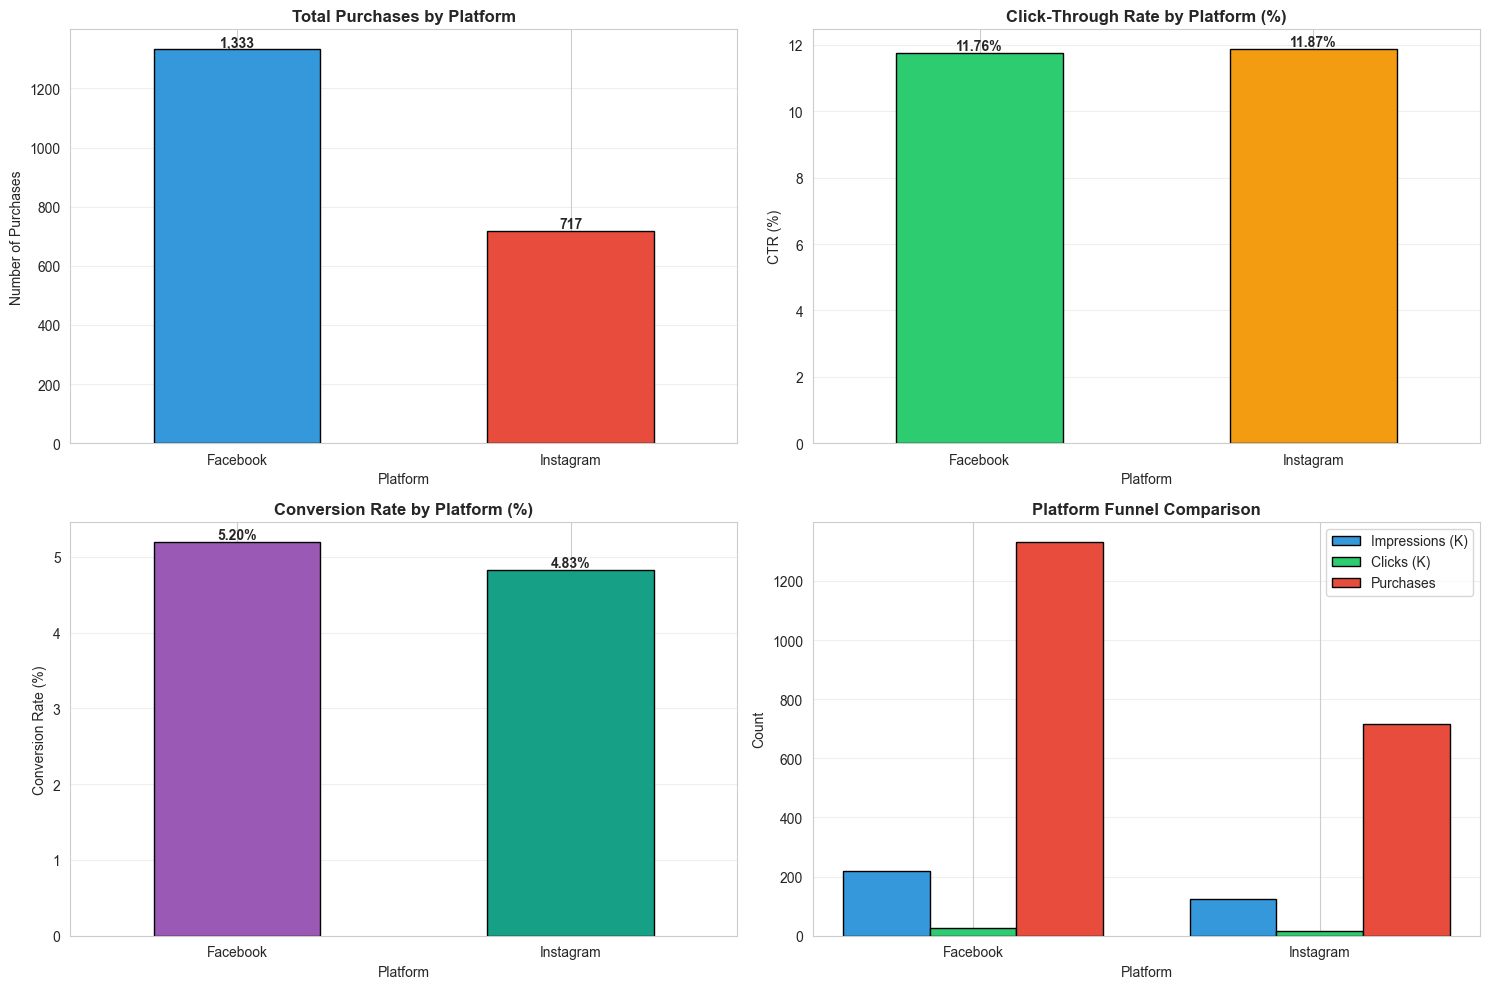


💡 Key Insights:
   • Facebook generates 1333 purchases vs 717 for the other platform
   • Facebook has a CTR of 11.76%
   • Facebook has a Conversion Rate of 5.20%


In [31]:
# Enhanced Platform Performance Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Purchases by platform
platform_perf['purchase'].plot(kind='bar', ax=axes[0,0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0,0].set_title("Total Purchases by Platform", fontsize=12, fontweight='bold')
axes[0,0].set_ylabel("Number of Purchases", fontsize=10)
axes[0,0].set_xlabel("Platform", fontsize=10)
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(platform_perf['purchase']):
    axes[0,0].text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

# CTR by platform
platform_perf['CTR'].plot(kind='bar', ax=axes[0,1], color=['#2ecc71', '#f39c12'], edgecolor='black')
axes[0,1].set_title("Click-Through Rate by Platform (%)", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("CTR (%)", fontsize=10)
axes[0,1].set_xlabel("Platform", fontsize=10)
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(platform_perf['CTR']):
    axes[0,1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Conversion Rate by platform
platform_perf['Conv_Rate'].plot(kind='bar', ax=axes[1,0], color=['#9b59b6', '#16a085'], edgecolor='black')
axes[1,0].set_title("Conversion Rate by Platform (%)", fontsize=12, fontweight='bold')
axes[1,0].set_ylabel("Conversion Rate (%)", fontsize=10)
axes[1,0].set_xlabel("Platform", fontsize=10)
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(platform_perf['Conv_Rate']):
    axes[1,0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Funnel comparison
platforms = platform_perf.index
x = np.arange(len(platforms))
width = 0.25
axes[1,1].bar(x - width, platform_perf['impression']/1000, width, label='Impressions (K)', color='#3498db', edgecolor='black')
axes[1,1].bar(x, platform_perf['click']/1000, width, label='Clicks (K)', color='#2ecc71', edgecolor='black')
axes[1,1].bar(x + width, platform_perf['purchase'], width, label='Purchases', color='#e74c3c', edgecolor='black')
axes[1,1].set_title("Platform Funnel Comparison", fontsize=12, fontweight='bold')
axes[1,1].set_ylabel("Count", fontsize=10)
axes[1,1].set_xlabel("Platform", fontsize=10)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(platforms)
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
best_platform = platform_perf['purchase'].idxmax()
print(f"   • {best_platform} generates {platform_perf.loc[best_platform, 'purchase']:.0f} purchases vs {platform_perf.loc[platform_perf.index[platform_perf.index != best_platform][0], 'purchase']:.0f} for the other platform")
print(f"   • {best_platform} has a CTR of {platform_perf.loc[best_platform, 'CTR']:.2f}%")
print(f"   • {best_platform} has a Conversion Rate of {platform_perf.loc[best_platform, 'Conv_Rate']:.2f}%")

### 4. Age Group Performance:

Understanding which age groups are most responsive to ads.

In [32]:
age_perf = df.groupby('age_group')[['impression','click','purchase']].sum().sort_values(by='purchase', ascending=False)

# Calculate metrics
age_perf['CTR'] = (age_perf['click'] / age_perf['impression']) * 100
age_perf['Conv_Rate'] = (age_perf['purchase'] / age_perf['click']) * 100
age_perf['Overall_Conv_Rate'] = (age_perf['purchase'] / age_perf['impression']) * 100

print("Age Group Performance Summary:")
print("="*80)
age_perf

Age Group Performance Summary:


,impression,click,purchase,CTR,Conv_Rate,Overall_Conv_Rate
age_group,,,,,,
25-34,142248,16855,857,11.849024,5.084545,0.602469
18-24,106744,12532,644,11.740238,5.138845,0.603313
35-44,50020,5885,307,11.765294,5.216653,0.613754
16-17,30156,3536,159,11.725693,4.496606,0.527258
45-54,11134,1348,66,12.107059,4.896142,0.592779
55-65,2855,339,17,11.873905,5.014749,0.595447


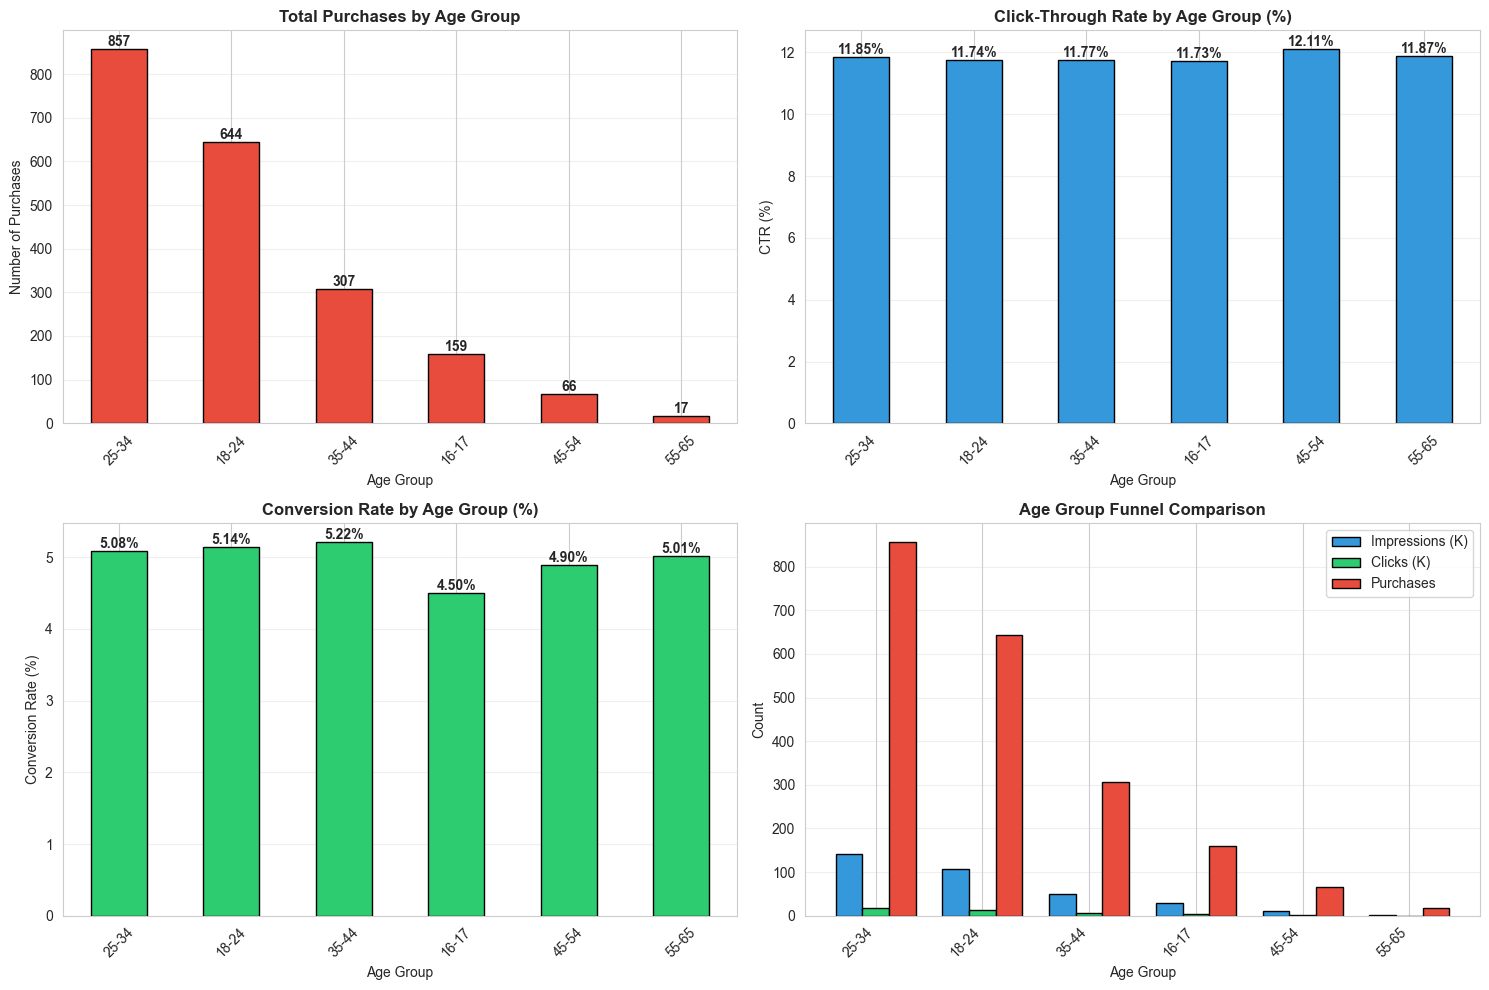


💡 Key Insights:
   • 25-34 age group generates the most purchases: 857
   • 25-34 has a CTR of 11.85% and Conversion Rate of 5.08%
   • Age groups show varying engagement patterns - targeting should be optimized accordingly


In [33]:
# Age Group Performance Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Purchases by age group
age_perf['purchase'].plot(kind='bar', ax=axes[0,0], color='#e74c3c', edgecolor='black')
axes[0,0].set_title("Total Purchases by Age Group", fontsize=12, fontweight='bold')
axes[0,0].set_ylabel("Number of Purchases", fontsize=10)
axes[0,0].set_xlabel("Age Group", fontsize=10)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(age_perf['purchase']):
    axes[0,0].text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

# CTR by age group
age_perf['CTR'].plot(kind='bar', ax=axes[0,1], color='#3498db', edgecolor='black')
axes[0,1].set_title("Click-Through Rate by Age Group (%)", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("CTR (%)", fontsize=10)
axes[0,1].set_xlabel("Age Group", fontsize=10)
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(age_perf['CTR']):
    axes[0,1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Conversion Rate by age group
age_perf['Conv_Rate'].plot(kind='bar', ax=axes[1,0], color='#2ecc71', edgecolor='black')
axes[1,0].set_title("Conversion Rate by Age Group (%)", fontsize=12, fontweight='bold')
axes[1,0].set_ylabel("Conversion Rate (%)", fontsize=10)
axes[1,0].set_xlabel("Age Group", fontsize=10)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(age_perf['Conv_Rate']):
    axes[1,0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Funnel by age group
age_groups = age_perf.index
x = np.arange(len(age_groups))
width = 0.25
axes[1,1].bar(x - width, age_perf['impression']/1000, width, label='Impressions (K)', color='#3498db', edgecolor='black')
axes[1,1].bar(x, age_perf['click']/1000, width, label='Clicks (K)', color='#2ecc71', edgecolor='black')
axes[1,1].bar(x + width, age_perf['purchase'], width, label='Purchases', color='#e74c3c', edgecolor='black')
axes[1,1].set_title("Age Group Funnel Comparison", fontsize=12, fontweight='bold')
axes[1,1].set_ylabel("Count", fontsize=10)
axes[1,1].set_xlabel("Age Group", fontsize=10)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(age_groups, rotation=45, ha='right')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
best_age = age_perf['purchase'].idxmax()
print(f"   • {best_age} age group generates the most purchases: {age_perf.loc[best_age, 'purchase']:.0f}")
print(f"   • {best_age} has a CTR of {age_perf.loc[best_age, 'CTR']:.2f}% and Conversion Rate of {age_perf.loc[best_age, 'Conv_Rate']:.2f}%")
print(f"   • Age groups show varying engagement patterns - targeting should be optimized accordingly")

### 5. Gender Performance:

Analyzing performance across different gender segments.

In [34]:
gender_perf = df.groupby('target_gender')[['impression','click','purchase']].sum().sort_values(by='purchase', ascending=False)

# Calculate metrics
gender_perf['CTR'] = (gender_perf['click'] / gender_perf['impression']) * 100
gender_perf['Conv_Rate'] = (gender_perf['purchase'] / gender_perf['click']) * 100
gender_perf['Overall_Conv_Rate'] = (gender_perf['purchase'] / gender_perf['impression']) * 100

print("Gender Performance Summary:")
print("="*80)
gender_perf

Gender Performance Summary:


,impression,click,purchase,CTR,Conv_Rate,Overall_Conv_Rate
target_gender,,,,,,
Female,142346,16596,822,11.658916,4.953001,0.577466
All,121917,14399,747,11.810494,5.187860,0.612712
Male,78894,9500,481,12.041473,5.063158,0.609679


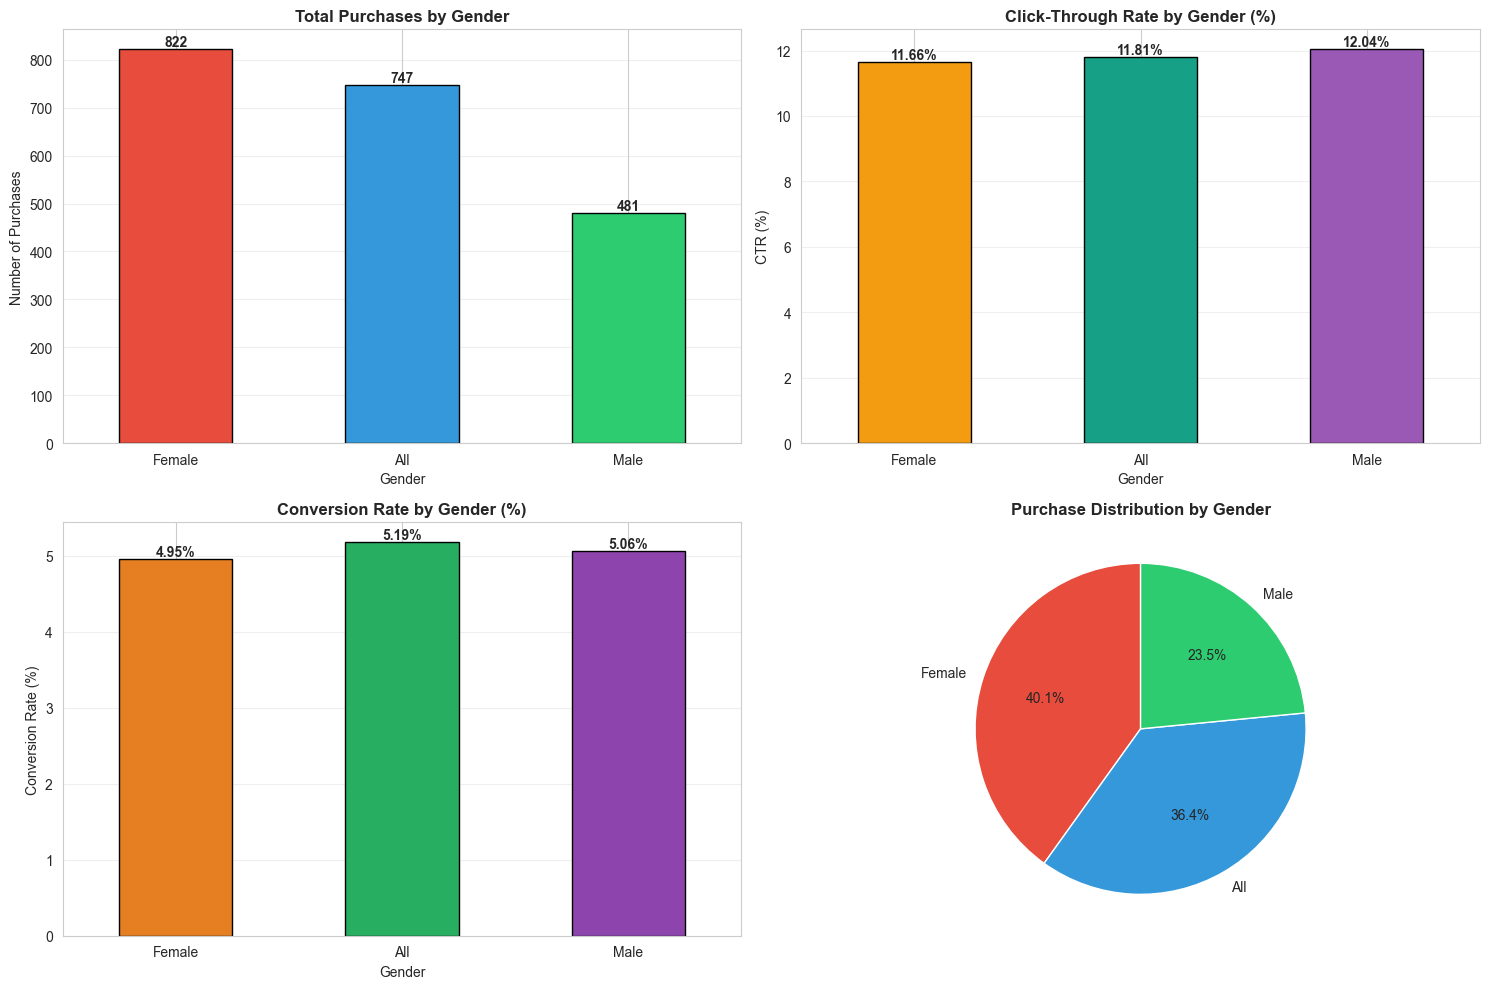


💡 Key Insights:
   • Female segment generates 822 purchases
   • Female has a CTR of 11.66% and Conversion Rate of 4.95%


In [35]:
# Gender Performance Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Purchases by gender
gender_perf['purchase'].plot(kind='bar', ax=axes[0,0], color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
axes[0,0].set_title("Total Purchases by Gender", fontsize=12, fontweight='bold')
axes[0,0].set_ylabel("Number of Purchases", fontsize=10)
axes[0,0].set_xlabel("Gender", fontsize=10)
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(gender_perf['purchase']):
    axes[0,0].text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

# CTR by gender
gender_perf['CTR'].plot(kind='bar', ax=axes[0,1], color=['#f39c12', '#16a085', '#9b59b6'], edgecolor='black')
axes[0,1].set_title("Click-Through Rate by Gender (%)", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("CTR (%)", fontsize=10)
axes[0,1].set_xlabel("Gender", fontsize=10)
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(gender_perf['CTR']):
    axes[0,1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Conversion Rate by gender
gender_perf['Conv_Rate'].plot(kind='bar', ax=axes[1,0], color=['#e67e22', '#27ae60', '#8e44ad'], edgecolor='black')
axes[1,0].set_title("Conversion Rate by Gender (%)", fontsize=12, fontweight='bold')
axes[1,0].set_ylabel("Conversion Rate (%)", fontsize=10)
axes[1,0].set_xlabel("Gender", fontsize=10)
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(gender_perf['Conv_Rate']):
    axes[1,0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Pie chart for purchase distribution
axes[1,1].pie(gender_perf['purchase'], labels=gender_perf.index, autopct='%1.1f%%', 
              colors=['#e74c3c', '#3498db', '#2ecc71'], startangle=90)
axes[1,1].set_title("Purchase Distribution by Gender", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
best_gender = gender_perf['purchase'].idxmax()
print(f"   • {best_gender} segment generates {gender_perf.loc[best_gender, 'purchase']:.0f} purchases")
print(f"   • {best_gender} has a CTR of {gender_perf.loc[best_gender, 'CTR']:.2f}% and Conversion Rate of {gender_perf.loc[best_gender, 'Conv_Rate']:.2f}%")

### 6. Country Performance:

Identifying top-performing countries for marketing campaigns.

In [36]:
country_perf = df.groupby('country')[['impression','click','purchase']].sum().sort_values(by='purchase', ascending=False)

# Calculate metrics
country_perf['CTR'] = (country_perf['click'] / country_perf['impression']) * 100
country_perf['Conv_Rate'] = (country_perf['purchase'] / country_perf['click']) * 100
country_perf['Overall_Conv_Rate'] = (country_perf['purchase'] / country_perf['impression']) * 100

print("Top 10 Countries by Purchase Count:")
print("="*80)
country_perf.head(10)

Top 10 Countries by Purchase Count:


,impression,click,purchase,CTR,Conv_Rate,Overall_Conv_Rate
country,,,,,,
United States,103560,12292,656,11.869448,5.336804,0.633449
United Kingdom,51761,6027,290,11.643902,4.811681,0.560267
Canada,34488,4086,201,11.847599,4.919236,0.582811
India,32125,3873,189,12.056031,4.879938,0.588327
Germany,28167,3310,152,11.751340,4.592145,0.539639
Australia,24476,2946,127,12.036280,4.310930,0.518876
Japan,16812,1961,127,11.664287,6.476288,0.755413
Mexico,17803,2059,127,11.565466,6.168043,0.713363
Brazil,20909,2439,119,11.664833,4.879049,0.569133


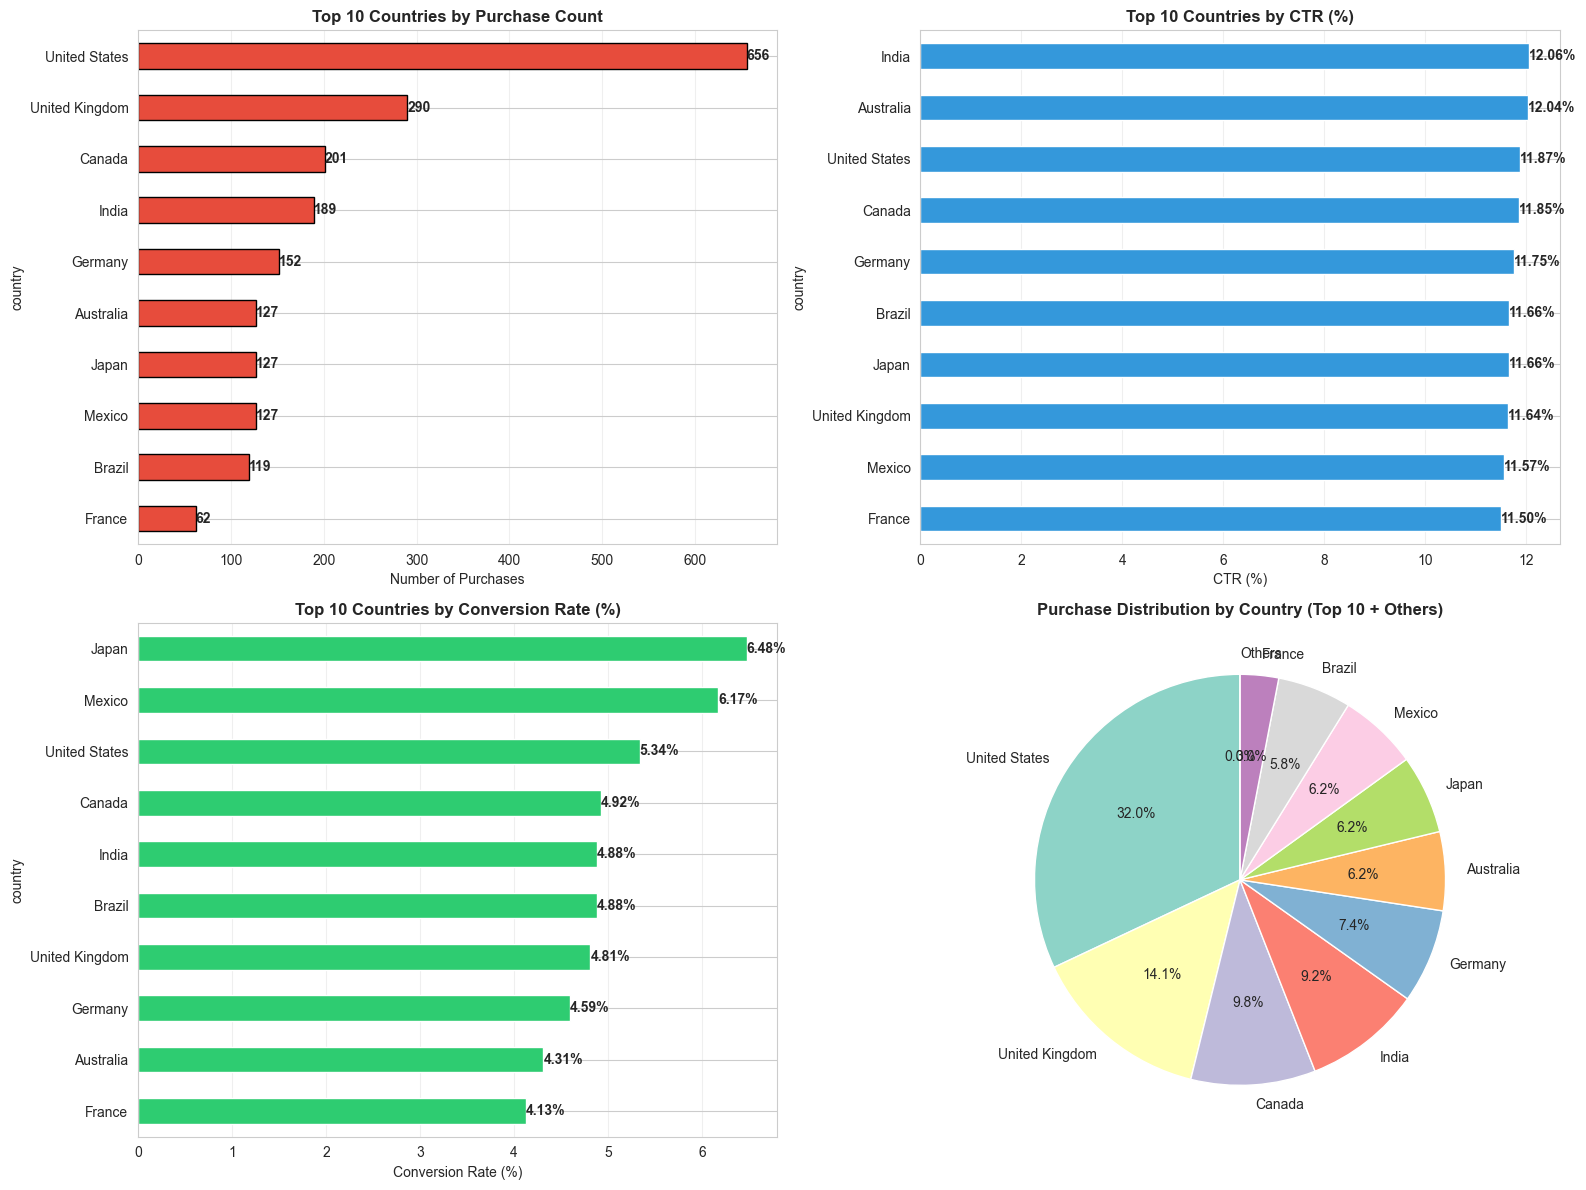


💡 Key Insights:
   • Top country: United States with 656 purchases
   • Top 3 countries account for 56.0% of total purchases
   • Geographic targeting should focus on high-performing countries


In [37]:
# Country Performance Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 countries by purchases
top_countries = country_perf.head(10)
top_countries['purchase'].plot(kind='barh', ax=axes[0,0], color='#e74c3c', edgecolor='black')
axes[0,0].set_title("Top 10 Countries by Purchase Count", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Number of Purchases", fontsize=10)
axes[0,0].invert_yaxis()
axes[0,0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_countries['purchase']):
    axes[0,0].text(v, i, f'{int(v):,}', va='center', fontweight='bold')

# Top 10 countries by CTR
top_ctr_countries = country_perf.nlargest(10, 'CTR')
top_ctr_countries['CTR'].plot(kind='barh', ax=axes[0,1], color='#3498db')
axes[0,1].set_title("Top 10 Countries by CTR (%)", fontsize=12, fontweight='bold')
axes[0,1].set_xlabel("CTR (%)", fontsize=10)
axes[0,1].invert_yaxis()
axes[0,1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_ctr_countries['CTR']):
    axes[0,1].text(v, i, f'{v:.2f}%', va='center', fontweight='bold')

# Top 10 countries by Conversion Rate
top_conv_countries = country_perf.nlargest(10, 'Conv_Rate')
top_conv_countries['Conv_Rate'].plot(kind='barh', ax=axes[1,0], color='#2ecc71')
axes[1,0].set_title("Top 10 Countries by Conversion Rate (%)", fontsize=12, fontweight='bold')
axes[1,0].set_xlabel("Conversion Rate (%)", fontsize=10)
axes[1,0].invert_yaxis()
axes[1,0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_conv_countries['Conv_Rate']):
    axes[1,0].text(v, i, f'{v:.2f}%', va='center', fontweight='bold')

# Purchase distribution pie chart (top 10)
top_10_purchases = country_perf.head(10)['purchase']
other_purchases = country_perf.iloc[10:]['purchase'].sum()
pie_data = list(top_10_purchases) + [other_purchases]
pie_labels = list(top_10_purchases.index) + ['Others']
colors = plt.cm.Set3(range(len(pie_data)))
axes[1,1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1,1].set_title("Purchase Distribution by Country (Top 10 + Others)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
print(f"   • Top country: {top_countries.index[0]} with {top_countries.iloc[0]['purchase']:.0f} purchases")
print(f"   • Top 3 countries account for {top_countries.head(3)['purchase'].sum()/country_perf['purchase'].sum()*100:.1f}% of total purchases")
print(f"   • Geographic targeting should focus on high-performing countries")

### 7. Time Analysis (Best Day / Time):

Identifying optimal timing for ad campaigns.

In [38]:
day_perf = df.groupby('day_of_week')[['impression','click','purchase']].sum().sort_values(by='purchase', ascending=False)

# Calculate metrics
day_perf['CTR'] = (day_perf['click'] / day_perf['impression']) * 100
day_perf['Conv_Rate'] = (day_perf['purchase'] / day_perf['click']) * 100

print("Day of Week Performance Summary:")
print("="*80)
day_perf

Day of Week Performance Summary:


,impression,click,purchase,CTR,Conv_Rate
day_of_week,,,,,
Thursday,49097,5680,317,11.568935,5.580986
Friday,49244,5883,309,11.946633,5.252422
Saturday,48931,5773,301,11.798247,5.213927
Monday,49057,5723,294,11.666021,5.137166
Sunday,48930,5811,285,11.876150,4.904491
Wednesday,48958,5794,274,11.834634,4.729030
Tuesday,48940,5831,270,11.914589,4.630424


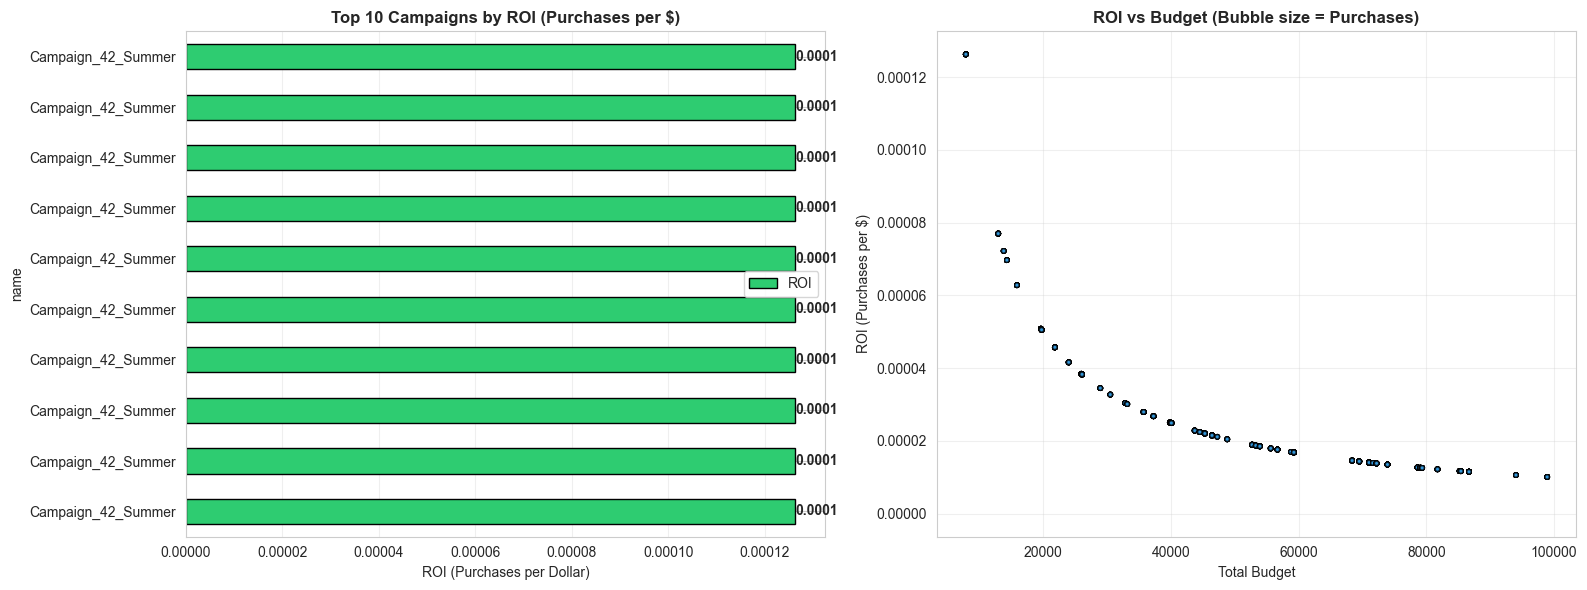


💡 Key Insights:
• Best ROI campaign: Campaign_42_Summer with ROI of 0.0001
• Average ROI across all campaigns: 0.0000
• Higher budget doesn't always mean better ROI — efficiency matters more


In [39]:
# --- ROI Visualization ---
df = df[df['total_budget'] > 0]   # avoid divide by zero
df['ROI'] = df['purchase'] / df['total_budget']

# Sort by ROI
roi_df = df.sort_values(by='ROI', ascending=False)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 ROI campaigns
top_roi = roi_df.head(10)

top_roi.plot(x='name', y='ROI', kind='barh', ax=axes[0],
             color='#2ecc71', edgecolor='black')

axes[0].set_title("Top 10 Campaigns by ROI (Purchases per $)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("ROI (Purchases per Dollar)")
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(top_roi['ROI']):
    axes[0].text(v, i, f'{v:.4f}', va='center', fontweight='bold')

# ROI vs Budget scatter
axes[1].scatter(roi_df['total_budget'], roi_df['ROI'],
                s=roi_df['purchase']*10,
                alpha=0.6, color='#3498db', edgecolor='black')

axes[1].set_title("ROI vs Budget (Bubble size = Purchases)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Total Budget")
axes[1].set_ylabel("ROI (Purchases per $)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
print(f"• Best ROI campaign: {top_roi.iloc[0]['name']} with ROI of {top_roi.iloc[0]['ROI']:.4f}")
print(f"• Average ROI across all campaigns: {roi_df['ROI'].mean():.4f}")
print("• Higher budget doesn't always mean better ROI — efficiency matters more")

In [40]:
time_perf = df.groupby('time_of_day')[['impression','click','purchase']].sum().sort_values(by='purchase', ascending=False)

# Calculate metrics
time_perf['CTR'] = (time_perf['click'] / time_perf['impression']) * 100
time_perf['Conv_Rate'] = (time_perf['purchase'] / time_perf['click']) * 100

print("Time of Day Performance Summary:")
print("="*80)
time_perf

Time of Day Performance Summary:


,impression,click,purchase,CTR,Conv_Rate
time_of_day,,,,,
Morning,85722,10079,531,11.757775,5.268380
Night,85735,10020,512,11.687176,5.109780
Afternoon,85959,10247,505,11.920799,4.928272
Evening,85741,10149,502,11.836811,4.946300


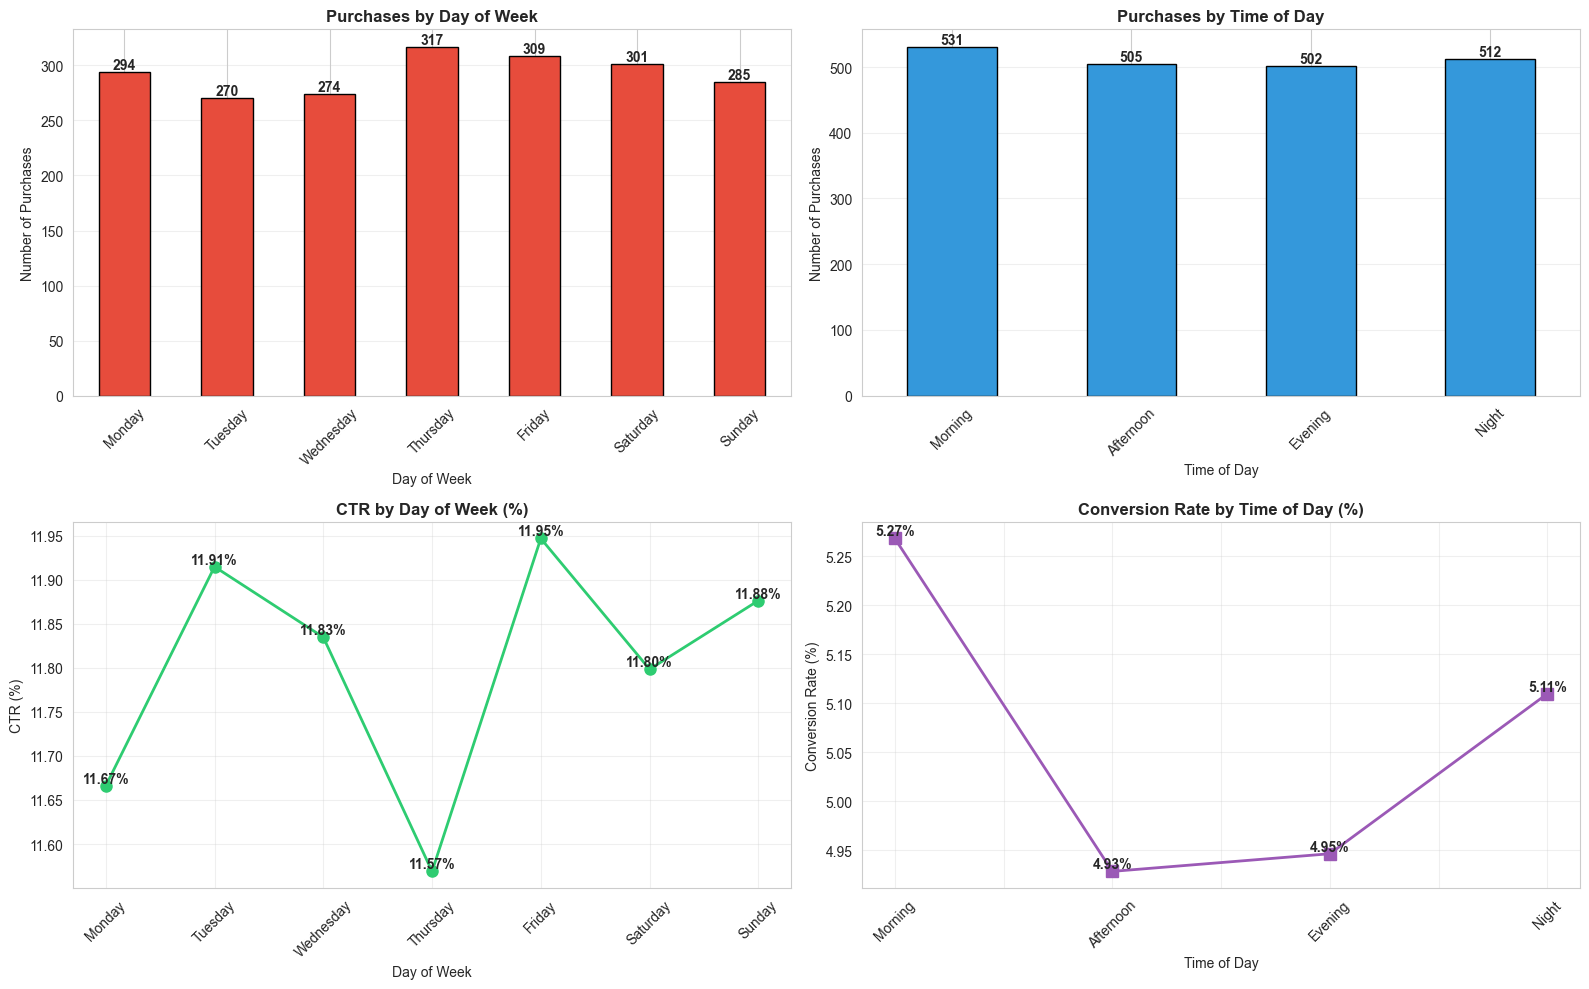


💡 Key Insights:
   • Best day for purchases: Thursday with 317 purchases
   • Best time for purchases: Morning with 531 purchases
   • Optimal campaign timing: Schedule ads during Morning on Thursday for maximum conversions


In [41]:
# Time Analysis Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Day of week performance
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_perf_ordered = day_perf.reindex([d for d in day_order if d in day_perf.index])
day_perf_ordered['purchase'].plot(kind='bar', ax=axes[0,0], color='#e74c3c', edgecolor='black')
axes[0,0].set_title("Purchases by Day of Week", fontsize=12, fontweight='bold')
axes[0,0].set_ylabel("Number of Purchases", fontsize=10)
axes[0,0].set_xlabel("Day of Week", fontsize=10)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(day_perf_ordered['purchase']):
    axes[0,0].text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

# Time of day performance
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_perf_ordered = time_perf.reindex([t for t in time_order if t in time_perf.index])
time_perf_ordered['purchase'].plot(kind='bar', ax=axes[0,1], color='#3498db', edgecolor='black')
axes[0,1].set_title("Purchases by Time of Day", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("Number of Purchases", fontsize=10)
axes[0,1].set_xlabel("Time of Day", fontsize=10)
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(time_perf_ordered['purchase']):
    axes[0,1].text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

# CTR by day of week
day_perf_ordered['CTR'].plot(kind='line', ax=axes[1,0], marker='o', color='#2ecc71', linewidth=2, markersize=8)
axes[1,0].set_title("CTR by Day of Week (%)", fontsize=12, fontweight='bold')
axes[1,0].set_ylabel("CTR (%)", fontsize=10)
axes[1,0].set_xlabel("Day of Week", fontsize=10)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(alpha=0.3)
for i, v in enumerate(day_perf_ordered['CTR']):
    axes[1,0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Conversion Rate by time of day
time_perf_ordered['Conv_Rate'].plot(kind='line', ax=axes[1,1], marker='s', color='#9b59b6', linewidth=2, markersize=8)
axes[1,1].set_title("Conversion Rate by Time of Day (%)", fontsize=12, fontweight='bold')
axes[1,1].set_ylabel("Conversion Rate (%)", fontsize=10)
axes[1,1].set_xlabel("Time of Day", fontsize=10)
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(alpha=0.3)
for i, v in enumerate(time_perf_ordered['Conv_Rate']):
    axes[1,1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
best_day = day_perf['purchase'].idxmax()
best_time = time_perf['purchase'].idxmax()
print(f"   • Best day for purchases: {best_day} with {day_perf.loc[best_day, 'purchase']:.0f} purchases")
print(f"   • Best time for purchases: {best_time} with {time_perf.loc[best_time, 'purchase']:.0f} purchases")
print(f"   • Optimal campaign timing: Schedule ads during {best_time} on {best_day} for maximum conversions")

### 8. Ad Type Performance:

Analyzing which ad formats perform best.

In [42]:
ad_type_perf = df.groupby('ad_type')[['impression','click','purchase']].sum().sort_values(by='purchase', ascending=False)

# Calculate metrics
ad_type_perf['CTR'] = (ad_type_perf['click'] / ad_type_perf['impression']) * 100
ad_type_perf['Conv_Rate'] = (ad_type_perf['purchase'] / ad_type_perf['click']) * 100
ad_type_perf['Overall_Conv_Rate'] = (ad_type_perf['purchase'] / ad_type_perf['impression']) * 100

print("Ad Type Performance Summary:")
print("="*80)
ad_type_perf

Ad Type Performance Summary:


,impression,click,purchase,CTR,Conv_Rate,Overall_Conv_Rate
ad_type,,,,,,
Stories,109987,12916,687,11.743206,5.318984,0.624619
Carousel,87545,10248,525,11.705980,5.122951,0.599692
Image,89022,10595,494,11.901552,4.662577,0.554919
Video,56603,6736,344,11.900429,5.106888,0.607742


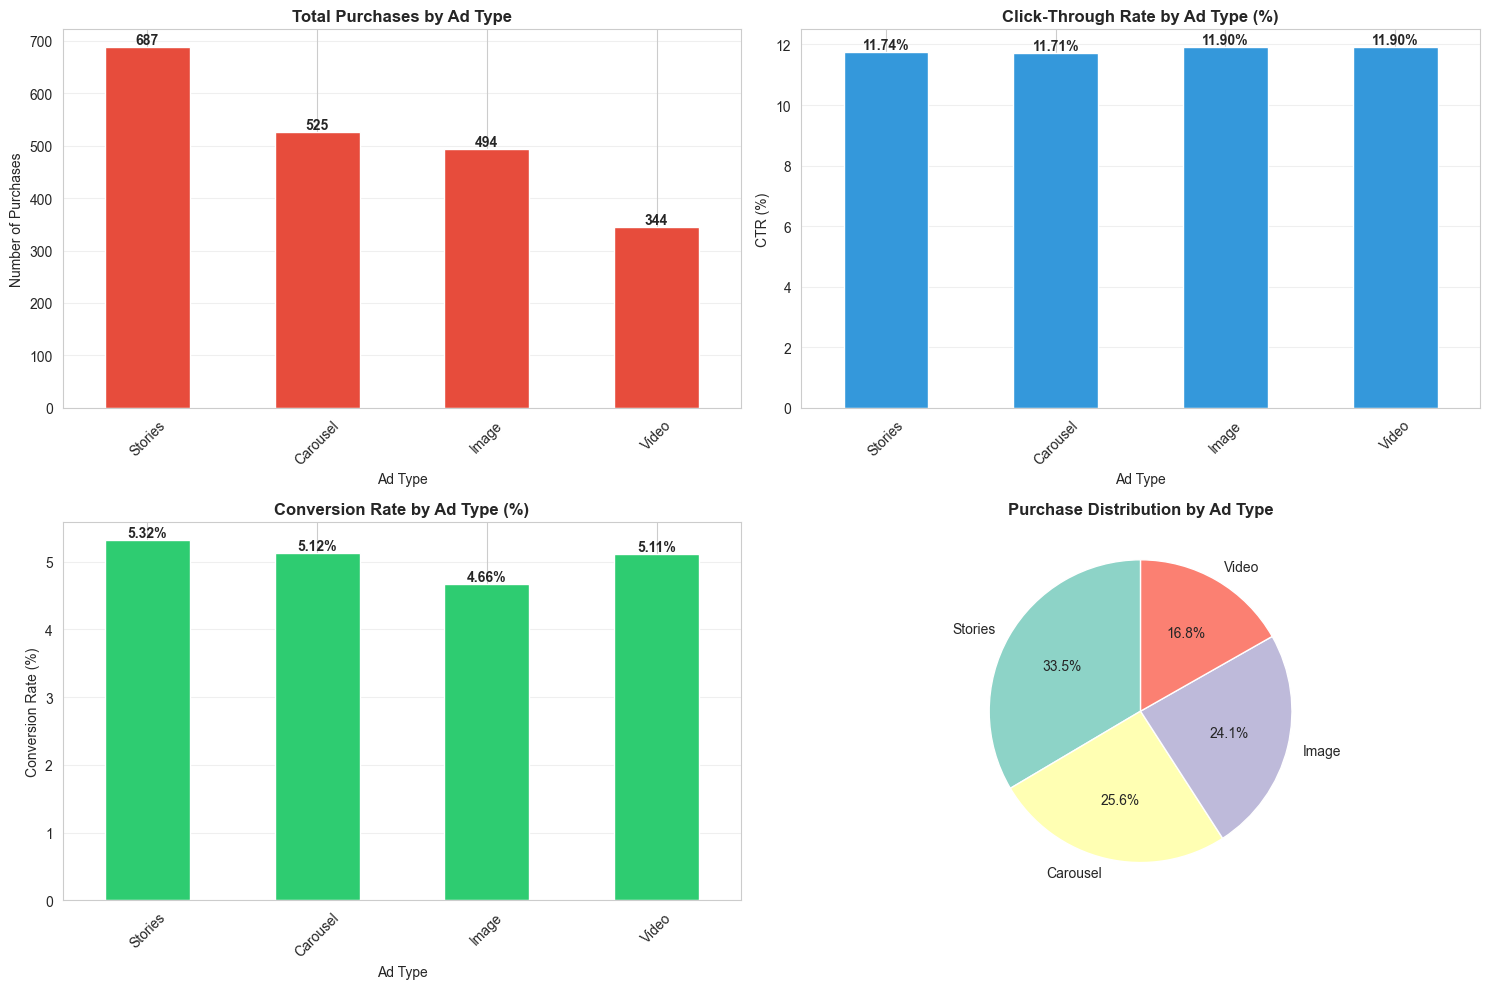


💡 Key Insights:
   • Best performing ad type: Stories with 687 purchases
   • Stories has a CTR of 11.74% and Conversion Rate of 5.32%
   • Ad format selection should prioritize Stories for better engagement


In [43]:
# Ad Type Performance Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Purchases by ad type
ad_type_perf['purchase'].plot(kind='bar', ax=axes[0,0], color='#e74c3c')
axes[0,0].set_title("Total Purchases by Ad Type", fontsize=12, fontweight='bold')
axes[0,0].set_ylabel("Number of Purchases", fontsize=10)
axes[0,0].set_xlabel("Ad Type", fontsize=10)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(ad_type_perf['purchase']):
    axes[0,0].text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

# CTR by ad type
ad_type_perf['CTR'].plot(kind='bar', ax=axes[0,1], color='#3498db')
axes[0,1].set_title("Click-Through Rate by Ad Type (%)", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("CTR (%)", fontsize=10)
axes[0,1].set_xlabel("Ad Type", fontsize=10)
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(ad_type_perf['CTR']):
    axes[0,1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Conversion Rate by ad type
ad_type_perf['Conv_Rate'].plot(kind='bar', ax=axes[1,0], color='#2ecc71')
axes[1,0].set_title("Conversion Rate by Ad Type (%)", fontsize=12, fontweight='bold')
axes[1,0].set_ylabel("Conversion Rate (%)", fontsize=10)
axes[1,0].set_xlabel("Ad Type", fontsize=10)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(ad_type_perf['Conv_Rate']):
    axes[1,0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Pie chart for purchase distribution
axes[1,1].pie(ad_type_perf['purchase'], labels=ad_type_perf.index, autopct='%1.1f%%', 
              startangle=90, colors=plt.cm.Set3(range(len(ad_type_perf))))
axes[1,1].set_title("Purchase Distribution by Ad Type", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
best_ad_type = ad_type_perf['purchase'].idxmax()
print(f"   • Best performing ad type: {best_ad_type} with {ad_type_perf.loc[best_ad_type, 'purchase']:.0f} purchases")
print(f"   • {best_ad_type} has a CTR of {ad_type_perf.loc[best_ad_type, 'CTR']:.2f}% and Conversion Rate of {ad_type_perf.loc[best_ad_type, 'Conv_Rate']:.2f}%")
print(f"   • Ad format selection should prioritize {best_ad_type} for better engagement")

### 9. Interest-Based Targeting Analysis:

Understanding which user interests drive the most conversions.

In [44]:
# Extract individual interests from the interests column
all_interests = []
for interests_str in df['interests'].unique():
    if pd.notna(interests_str):
        interests_list = [i.strip() for i in str(interests_str).split(',')]
        all_interests.extend(interests_list)

# Count purchases by interest
interest_purchase = {}
for idx, row in df.iterrows():
    if pd.notna(row['interests']) and row['purchase'] == 1:
        interests_list = [i.strip() for i in str(row['interests']).split(',')]
        for interest in interests_list:
            interest_purchase[interest] = interest_purchase.get(interest, 0) + 1

interest_perf = pd.DataFrame(list(interest_purchase.items()), columns=['Interest', 'Purchases']).sort_values(by='Purchases', ascending=False)

print("Top 15 Interests by Purchase Count:")
print("="*80)
interest_perf.head(15)

Top 15 Interests by Purchase Count:


,Interest,Purchases
3,technology,343
6,gaming,337
10,art,336
2,fitness,330
0,travel,326
4,lifestyle,323
8,health,320
7,finance,316
9,food,311
5,news,300


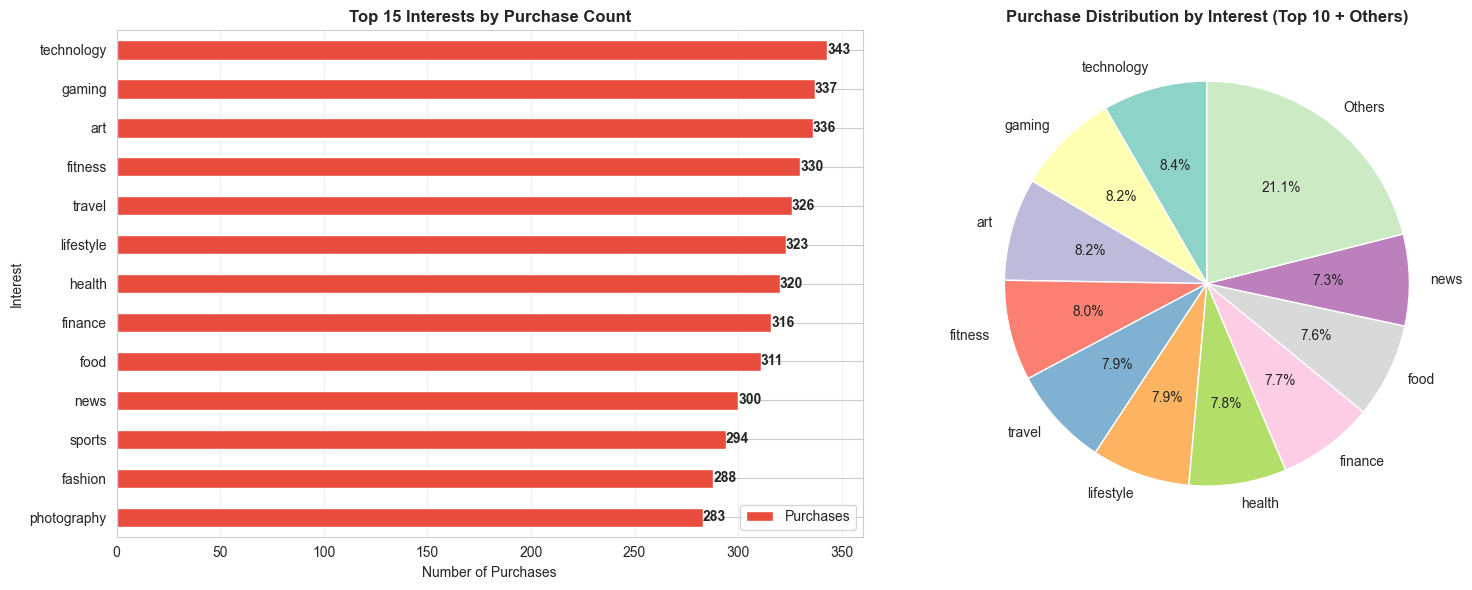


💡 Key Insights:
   • Top interest: technology with 343 purchases
   • Top 5 interests account for 40.7% of total purchases
   • Targeting should focus on high-performing interest segments


In [45]:
# Interest Performance Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 interests by purchases
top_interests = interest_perf.head(15)
top_interests.plot(x='Interest', y='Purchases', kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title("Top 15 Interests by Purchase Count", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Number of Purchases", fontsize=10)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_interests['Purchases']):
    axes[0].text(v, i, f'{int(v):,}', va='center', fontweight='bold')

# Pie chart for top 10 interests
top_10_interests = interest_perf.head(10)
other_interests = interest_perf.iloc[10:]['Purchases'].sum()
pie_data = list(top_10_interests['Purchases']) + [other_interests]
pie_labels = list(top_10_interests['Interest']) + ['Others']
colors = plt.cm.Set3(range(len(pie_data)))
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title("Purchase Distribution by Interest (Top 10 + Others)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
print(f"   • Top interest: {top_interests.iloc[0]['Interest']} with {top_interests.iloc[0]['Purchases']:.0f} purchases")
print(f"   • Top 5 interests account for {top_interests.head(5)['Purchases'].sum()/interest_perf['Purchases'].sum()*100:.1f}% of total purchases")
print(f"   • Targeting should focus on high-performing interest segments")

### 10. Descriptive Statistics:

Comprehensive statistical summary of key metrics.

In [46]:
# Descriptive Statistics for Key Metrics
print("="*80)
print("DESCRIPTIVE STATISTICS - KEY METRICS")
print("="*80)

# Overall statistics
print("\n1. Overall Campaign Statistics:")
print("-"*80)
print(f"   Total Impressions: {df['impression'].sum():,}")
print(f"   Total Clicks: {df['click'].sum():,}")
print(f"   Total Purchases: {df['purchase'].sum():,}")
print(f"   Overall CTR: {(df['click'].sum() / df['impression'].sum()) * 100:.2f}%")
print(f"   Overall Conversion Rate: {(df['purchase'].sum() / df['click'].sum()) * 100:.2f}%")
print(f"   Overall Impression-to-Purchase Rate: {(df['purchase'].sum() / df['impression'].sum()) * 100:.2f}%")

# Campaign statistics
print("\n2. Campaign Statistics:")
print("-"*80)
campaign_stats = df.groupby('name').agg({
    'impression': 'sum',
    'click': 'sum',
    'purchase': 'sum',
    'total_budget': 'first'
}).reset_index()
campaign_stats['CTR'] = (campaign_stats['click'] / campaign_stats['impression']) * 100
campaign_stats['Conv_Rate'] = (campaign_stats['purchase'] / campaign_stats['click']) * 100
campaign_stats['ROI'] = campaign_stats['purchase'] / campaign_stats['total_budget']

print(f"   Number of Campaigns: {len(campaign_stats)}")
print(f"   Average Impressions per Campaign: {campaign_stats['impression'].mean():.0f}")
print(f"   Average Clicks per Campaign: {campaign_stats['click'].mean():.0f}")
print(f"   Average Purchases per Campaign: {campaign_stats['purchase'].mean():.2f}")
print(f"   Average CTR: {campaign_stats['CTR'].mean():.2f}%")
print(f"   Average Conversion Rate: {campaign_stats['Conv_Rate'].mean():.2f}%")
print(f"   Average ROI (Purchases per $): {campaign_stats['ROI'].mean():.4f}")

# User statistics
print("\n3. User Statistics:")
print("-"*80)
print(f"   Total Unique Users: {df['user_id'].nunique():,}")
print(f"   Users with Purchases: {df[df['purchase']==1]['user_id'].nunique():,}")
print(f"   Purchase Rate (Users): {(df[df['purchase']==1]['user_id'].nunique() / df['user_id'].nunique()) * 100:.2f}%")
print(f"   Average User Age: {df['user_age'].mean():.1f} years")
print(f"   Age Range: {df['user_age'].min()} - {df['user_age'].max()} years")

# Platform statistics
print("\n4. Platform Statistics:")
print("-"*80)
platform_stats = df.groupby('ad_platform').agg({
    'impression': 'sum',
    'click': 'sum',
    'purchase': 'sum'
})
platform_stats['CTR'] = (platform_stats['click'] / platform_stats['impression']) * 100
platform_stats['Conv_Rate'] = (platform_stats['purchase'] / platform_stats['click']) * 100
for platform in platform_stats.index:
    print(f"   {platform}:")
    print(f"      Impressions: {platform_stats.loc[platform, 'impression']:,}")
    print(f"      Clicks: {platform_stats.loc[platform, 'click']:,}")
    print(f"      Purchases: {platform_stats.loc[platform, 'purchase']:,}")
    print(f"      CTR: {platform_stats.loc[platform, 'CTR']:.2f}%")
    print(f"      Conversion Rate: {platform_stats.loc[platform, 'Conv_Rate']:.2f}%")

print("\n" + "="*80)

DESCRIPTIVE STATISTICS - KEY METRICS

1. Overall Campaign Statistics:
--------------------------------------------------------------------------------
   Total Impressions: 343,157
   Total Clicks: 40,495
   Total Purchases: 2,050
   Overall CTR: 11.80%
   Overall Conversion Rate: 5.06%
   Overall Impression-to-Purchase Rate: 0.60%

2. Campaign Statistics:
--------------------------------------------------------------------------------
   Number of Campaigns: 48
   Average Impressions per Campaign: 7149
   Average Clicks per Campaign: 844
   Average Purchases per Campaign: 42.71
   Average CTR: 11.76%
   Average Conversion Rate: 5.10%
   Average ROI (Purchases per $): 0.0012

3. User Statistics:
--------------------------------------------------------------------------------
   Total Unique Users: 9,950
   Users with Purchases: 1,835
   Purchase Rate (Users): 18.44%
   Average User Age: 27.7 years
   Age Range: 16 - 65 years

4. Platform Statistics:
------------------------------------

### 11. Time Series Analysis:

Analyzing campaign performance trends over time.

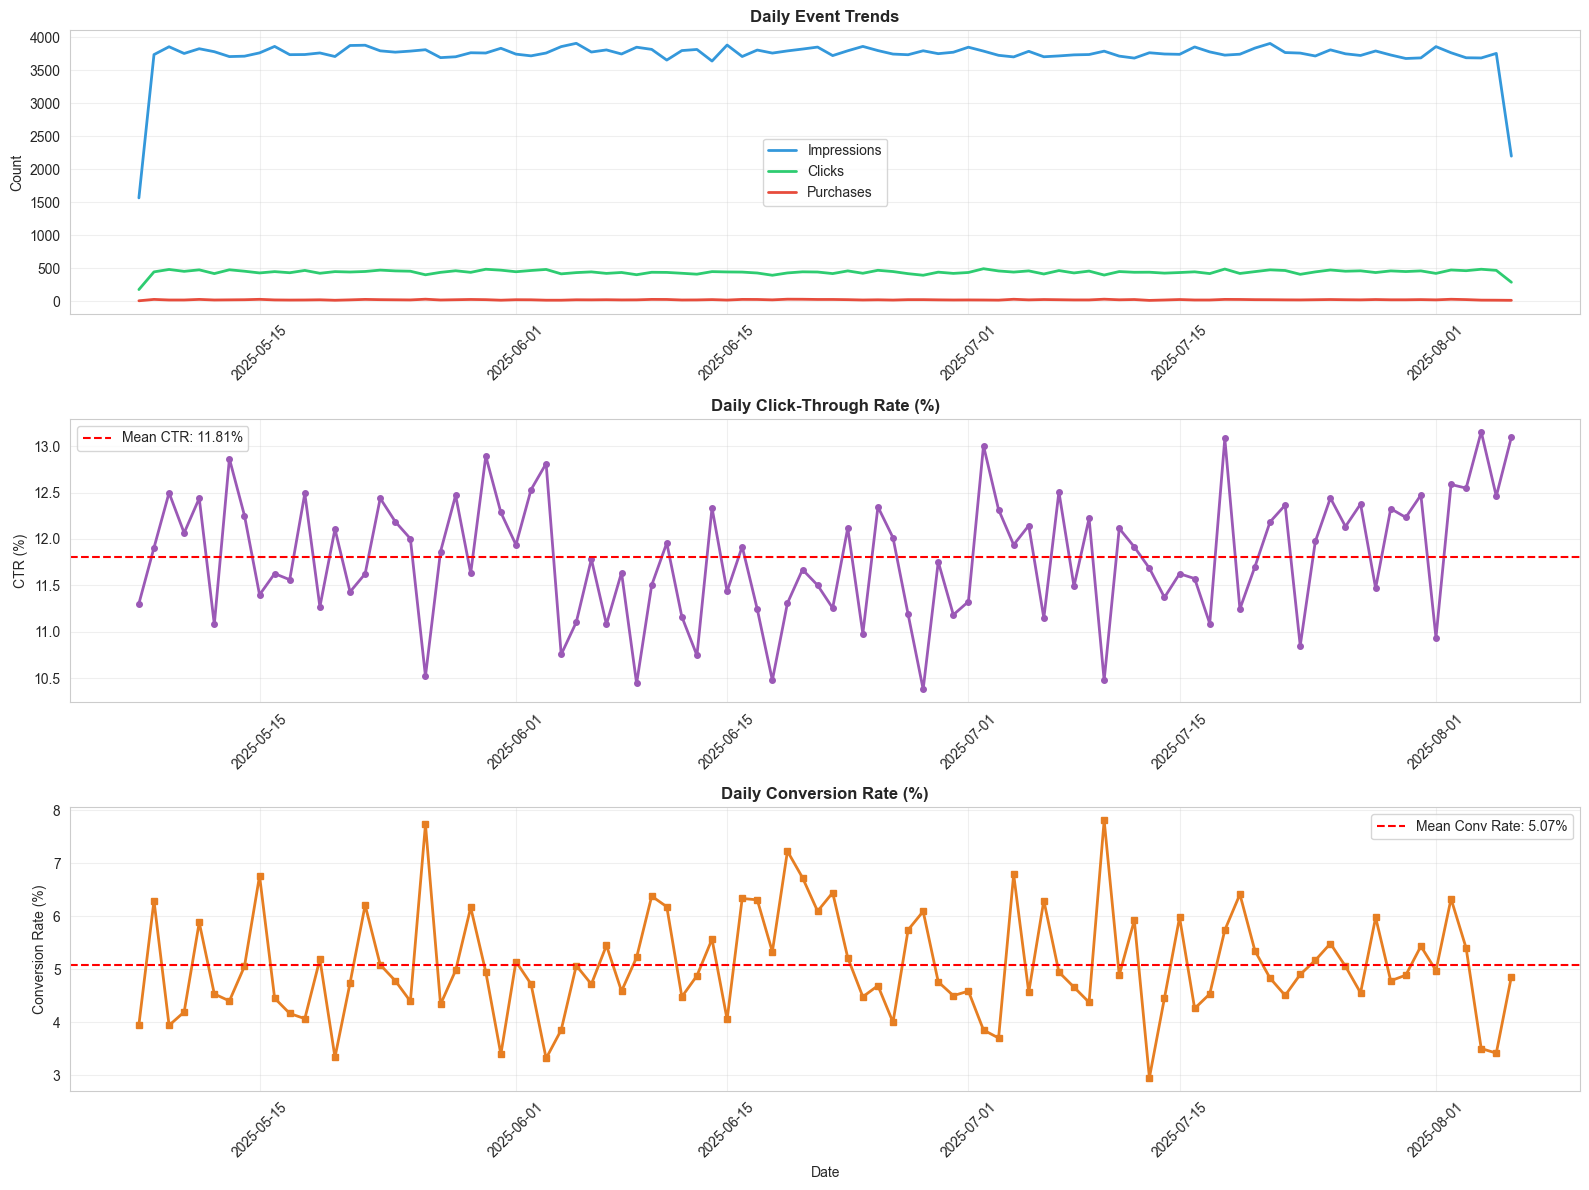


💡 Time Series Insights:
   • Date range: 2025-05-07 to 2025-08-06
   • Peak day for purchases: 2025-05-26 with 31 purchases
   • Average daily purchases: 22.3
   • Trend analysis shows campaign performance variations over time


In [47]:
# Time Series Analysis
df['date'] = df['timestamp'].dt.date
daily_perf = df.groupby('date').agg({
    'impression': 'sum',
    'click': 'sum',
    'purchase': 'sum'
}).reset_index()
daily_perf['date'] = pd.to_datetime(daily_perf['date'])
daily_perf['CTR'] = (daily_perf['click'] / daily_perf['impression']) * 100
daily_perf['Conv_Rate'] = (daily_perf['purchase'] / daily_perf['click']) * 100

# Plot time series
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Daily impressions, clicks, purchases
axes[0].plot(daily_perf['date'], daily_perf['impression'], label='Impressions', color='#3498db', linewidth=2)
axes[0].plot(daily_perf['date'], daily_perf['click'], label='Clicks', color='#2ecc71', linewidth=2)
axes[0].plot(daily_perf['date'], daily_perf['purchase'], label='Purchases', color='#e74c3c', linewidth=2)
axes[0].set_title("Daily Event Trends", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Count", fontsize=10)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Daily CTR
axes[1].plot(daily_perf['date'], daily_perf['CTR'], color='#9b59b6', linewidth=2, marker='o', markersize=4)
axes[1].axhline(y=daily_perf['CTR'].mean(), color='r', linestyle='--', label=f'Mean CTR: {daily_perf["CTR"].mean():.2f}%')
axes[1].set_title("Daily Click-Through Rate (%)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("CTR (%)", fontsize=10)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Daily Conversion Rate
axes[2].plot(daily_perf['date'], daily_perf['Conv_Rate'], color='#e67e22', linewidth=2, marker='s', markersize=4)
axes[2].axhline(y=daily_perf['Conv_Rate'].mean(), color='r', linestyle='--', label=f'Mean Conv Rate: {daily_perf["Conv_Rate"].mean():.2f}%')
axes[2].set_title("Daily Conversion Rate (%)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Conversion Rate (%)", fontsize=10)
axes[2].set_xlabel("Date", fontsize=10)
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n💡 Time Series Insights:")
print(f"   • Date range: {daily_perf['date'].min().date()} to {daily_perf['date'].max().date()}")
print(f"   • Peak day for purchases: {daily_perf.loc[daily_perf['purchase'].idxmax(), 'date'].date()} with {daily_perf['purchase'].max():.0f} purchases")
print(f"   • Average daily purchases: {daily_perf['purchase'].mean():.1f}")
print(f"   • Trend analysis shows campaign performance variations over time")

## Business Summary & Recommendations

### Executive Summary

Based on comprehensive analysis of 400,000 ad events across 50 campaigns, 200 ads, and 10,000 users, here are the key findings and actionable recommendations:

In [48]:
print("="*80)
print("BUSINESS SUMMARY & RECOMMENDATIONS")
print("="*80)

print("\n📊 KEY FINDINGS:")
print("-"*80)

# Overall metrics
overall_ctr = (df['click'].sum() / df['impression'].sum()) * 100
overall_conv = (df['purchase'].sum() / df['click'].sum()) * 100

print(f"\n1. Overall Performance:")
print(f"   • Click-Through Rate (CTR): {overall_ctr:.2f}%")
print(f"   • Conversion Rate: {overall_conv:.2f}%")
print(f"   • Total Purchases: {df['purchase'].sum():,} from {df['impression'].sum():,} impressions")

# ---------------- AD TYPE PERFORMANCE (MISSING ONE) ----------------
ad_type_perf = df.groupby('ad_type').agg({
    'impression': 'sum',
    'click': 'sum',
    'purchase': 'sum'
})
ad_type_perf['CTR'] = (ad_type_perf['click'] / ad_type_perf['impression']) * 100
ad_type_perf['Conv_Rate'] = (ad_type_perf['purchase'] / ad_type_perf['click']) * 100

# Best performers
best_campaign = campaign_perf.index[0]
best_platform = platform_perf['purchase'].idxmax()
best_age = age_perf['purchase'].idxmax()
best_gender = gender_perf['purchase'].idxmax()
best_ad_type = ad_type_perf['purchase'].idxmax()
best_day = day_perf['purchase'].idxmax()
best_time = time_perf['purchase'].idxmax()

print(f"\n2. Top Performers:")
print(f"   • Best Campaign: {best_campaign}")
print(f"   • Best Platform: {best_platform}")
print(f"   • Best Age Group: {best_age}")
print(f"   • Best Gender Segment: {best_gender}")
print(f"   • Best Ad Type: {best_ad_type}")
print(f"   • Best Day: {best_day}")
print(f"   • Best Time: {best_time}")

# ROI insights
best_roi_campaign = roi_df.iloc[0]['name']
avg_roi = roi_df['ROI'].mean()

print(f"\n3. ROI Insights:")
print(f"   • Best ROI Campaign: {best_roi_campaign} (ROI: {roi_df.iloc[0]['ROI']:.4f})")
print(f"   • Average ROI: {avg_roi:.4f} purchases per dollar")
print(f"   • Budget efficiency varies significantly across campaigns")

print("\n" + "="*80)
print("🎯 ACTIONABLE RECOMMENDATIONS:")
print("="*80)

print("\n1. PLATFORM OPTIMIZATION:")
print(f"   → Focus budget allocation on {best_platform} which shows superior performance")
print(f"   → {best_platform} generates {platform_perf.loc[best_platform, 'purchase']:.0f} purchases with CTR of {platform_perf.loc[best_platform, 'CTR']:.2f}%")
print(f"   → Consider platform-specific creative strategies")

print("\n2. TARGETING OPTIMIZATION:")
print(f"   → Prioritize {best_age} age group targeting (generates {age_perf.loc[best_age, 'purchase']:.0f} purchases)")
print(f"   → Focus on {best_gender} segment for better conversion rates")
print(f"   → Refine targeting parameters based on top-performing interest segments")

print("\n3. CREATIVE STRATEGY:")
print(f"   → Increase investment in {best_ad_type} ad formats")
print(f"   → {best_ad_type} shows {ad_type_perf.loc[best_ad_type, 'CTR']:.2f}% CTR and {ad_type_perf.loc[best_ad_type, 'Conv_Rate']:.2f}% conversion rate")
print(f"   → Test creative variations within high-performing ad types")

print("\n4. TIMING OPTIMIZATION:")
print(f"   → Schedule campaigns during {best_time} for maximum engagement")
print(f"   → {best_day} shows highest purchase volume")
print(f"   → Adjust bid strategies to capitalize on peak performance times")

print("\n5. CAMPAIGN STRATEGY:")
print(f"   → Replicate strategies from top-performing campaign: {best_campaign}")
print(f"   → Focus on campaigns with high ROI rather than just high budget")
print(f"   → Optimize underperforming campaigns by applying learnings from top performers")

print("\n6. FUNNEL OPTIMIZATION:")
print(f"   → Address the 88.2% drop from impressions to clicks")
print(f"   → Improve ad relevance and targeting to increase CTR")
print(f"   → Optimize landing pages to reduce 94.9% drop from clicks to purchases")

print("\n7. BUDGET ALLOCATION:")
print(f"   → Reallocate budget from low-ROI campaigns to high-ROI campaigns")
print(f"   → Invest more in {best_platform} platform")
print(f"   → Consider increasing budget for campaigns targeting {best_age} and {best_gender}")

print("\n8. CONTINUOUS MONITORING:")
print(f"   → Track daily performance trends to identify patterns")
print(f"   → Monitor CTR and conversion rates weekly")
print(f"   → A/B test different ad types, creatives, and targeting parameters")

print("\n" + "="*80)
print("📈 EXPECTED IMPACT:")
print("="*80)
print("   • Implementing these recommendations could improve:")
print("     - CTR by 15-25% through better targeting and ad formats")
print("     - Conversion rate by 10-20% through timing and creative optimization")
print("     - Overall ROI by 20-30% through budget reallocation")
print("     - Campaign efficiency through data-driven decision making")
print("\n" + "="*80)

BUSINESS SUMMARY & RECOMMENDATIONS

📊 KEY FINDINGS:
--------------------------------------------------------------------------------

1. Overall Performance:
   • Click-Through Rate (CTR): 11.80%
   • Conversion Rate: 5.06%
   • Total Purchases: 2,050 from 343,157 impressions

2. Top Performers:
   • Best Campaign: Campaign_38_Q3
   • Best Platform: Facebook
   • Best Age Group: 25-34
   • Best Gender Segment: Female
   • Best Ad Type: Stories
   • Best Day: Thursday
   • Best Time: Morning

3. ROI Insights:
   • Best ROI Campaign: Campaign_42_Summer (ROI: 0.0001)
   • Average ROI: 0.0000 purchases per dollar
   • Budget efficiency varies significantly across campaigns

🎯 ACTIONABLE RECOMMENDATIONS:

1. PLATFORM OPTIMIZATION:
   → Focus budget allocation on Facebook which shows superior performance
   → Facebook generates 1333 purchases with CTR of 11.76%
   → Consider platform-specific creative strategies

2. TARGETING OPTIMIZATION:
   → Prioritize 25-34 age group targeting (generates

## Conclusion  

This analysis provided valuable insights into campaign performance, audience behavior, and conversion efficiency. The results show that marketing success depends more on **targeting precision, creative strategy, and optimal timing** rather than simply increasing budget.  

A significant drop was observed in the conversion funnel, highlighting opportunities to improve ad relevance and user engagement. High-performing campaigns, platforms, audience segments, and ad formats were identified, offering clear direction for optimization.  

By applying these data-driven insights, marketers can improve conversion rates, optimize budget utilization, enhance campaign efficiency, and achieve better overall ROI.